# EDA

In [2]:
import pandas as pd
import numpy as np
from collections import Counter
pd.set_option('display.max_columns', None)

## Литрес

Рассмотрим датасет, полученный скрейпингом с сайта Литрес и обогращенный при помощи api гугл книг

In [5]:
df1 = pd.read_csv("google_x_litres_final.csv")
df1.head()

,Unnamed: 0.1,id_book,categories,publisher,description,print_type,page_count,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable,Unnamed: 0,title,author,isbn,pages,publication_year,rating,reviews_count,price,currency,age_restriction,genres,publisher.1,formats,url,price_numeric,rating_numeric,pages_numeric,reviews_numeric
0,0,1Y11EQAAQBAJ,['Fiction'],"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,NaN,582.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True,0,По осколкам твоего сердца,Анна Джейн,NaN,500.0,2025.0,4.9,3530.0,229.0,RUB,16+,"Литрес Авторы, От ненависти до любви, Первая л...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/po-osko...,229.0,4.9,500.0,3530.0
1,1,Cb-UEAAAQBAJ,['Young Adult Fiction'],"ЛитРес, SelfPub",Я вижу его каждый день в окне дома напротив. О...,NaN,611.0,ru,NL,FOR_SALE,True,2.22,EUR,PARTIAL,False,True,True,1,Твое сердце будет разбито,Анна Джейн,NaN,510.0,2022.0,4.8,7228.0,199.0,RUB,16+,"Литрес Авторы, Любовь и ненависть, Молодежные ...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/tvoe-se...,199.0,4.8,510.0,7228.0
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,Фейерверк на ладони,Ольга Назарова,NaN,430.0,2026.0,4.9,139.0,189.0,RUB,16+,"Антистресс, Ироничная проза, Книги для души, К...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/olga-stanislavovna-...,189.0,4.9,430.0,139.0
3,3,p4_kzgEACAAJ,NaN,Ast,NaN,NaN,576.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,NO_PAGES,False,False,False,3,Проект «Аве Мария»,Энди Вейер,NaN,21.0,2021.0,4.8,2117.0,529.0,RUB,16+,"Авантюрные приключения, Близкое будущее, Заруб...",Правообладатель: Аудио-ЛАУ,"m4b,, mp3,, zip",https://www.litres.ru/audiobook/endi-veyer/pro...,529.0,4.8,21.0,2117.0
4,4,1Y11EQAAQBAJ,['Fiction'],"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,NaN,582.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True,4,По осколкам твоего сердца,Анна Джейн,NaN,14.0,2022.0,4.8,921.0,749.0,RUB,16+,"Young adult, Книги о подростках, Любовь и нена...",Правообладатель: Издательство CLEVER,"m4b,, mp3,, zip",https://www.litres.ru/audiobook/anna-dzheyn/po...,749.0,4.8,14.0,921.0


In [6]:
df1.dtypes

Unnamed: 0.1          int64
id_book              object
categories           object
publisher            object
description          object
print_type          float64
page_count          float64
language             object
country              object
saleability          object
is_ebook             object
retail_price        float64
currency_code        object
viewability          object
public_domain        object
epub_avaliable       object
pdf_avaliable        object
Unnamed: 0            int64
title                object
author               object
isbn                 object
pages               float64
publication_year    float64
rating              float64
reviews_count       float64
price               float64
currency             object
age_restriction      object
genres               object
publisher.1          object
formats              object
url                  object
price_numeric       float64
rating_numeric      float64
pages_numeric       float64
reviews_numeric     

Удалим заведомо ненужные для анализа столбцы

In [8]:
df1 = df1.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "id_book", "price_numeric", "rating_numeric", "pages_numeric", "reviews_numeric"]) 

In [9]:
df1.shape

(10070, 29)

Переставим столбцы в более логичном для анализа порядке и переименуем некоторые столбцы для избежания разночтений

In [11]:
df1 = df1[["title", "author", "isbn", "rating", "reviews_count", "price", "currency", "publication_year", "pages", "age_restriction",
          "genres", "publisher.1", "formats", "url", "categories", "publisher", "description", "print_type", "page_count", "language", "country",
          "saleability", "is_ebook", "retail_price", "currency_code", "viewability", "public_domain", "epub_avaliable", "pdf_avaliable"]]

df1 = df1.rename(columns={"publisher.1":"lit_publisher", "publisher":"gb_publisher", "pages":"lit_pages", "page_count":"gb_pages"})

Рассмотрим полные дубликаты

In [13]:
n_duplicates = df1.duplicated(keep=False)
df1[n_duplicates].head(10)

,title,author,isbn,rating,reviews_count,price,currency,publication_year,lit_pages,age_restriction,genres,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable
647,Влюбленная ведьма,Анна Джейн,NaN,4.9,3536.0,179.0,RUB,2022.0,500.0,16+,"Литрес Авторы, Любовь и ненависть, Новый год, ...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/vlublen...,['College students'],NaN,NaN,NaN,0.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,NO_PAGES,False,False,False
648,Влюбленная ведьма,Анна Джейн,NaN,4.9,3536.0,179.0,RUB,2022.0,500.0,16+,"Литрес Авторы, Любовь и ненависть, Новый год, ...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/vlublen...,['College students'],NaN,NaN,NaN,0.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,NO_PAGES,False,False,False
719,Звездная Кровь – 2. Фригольд,Роман Прокофьев,NaN,4.9,2594.0,159.0,RUB,2023.0,290.0,18+,"LitRPG, Боевая фантастика, Героическое фэнтези...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/roman-urevich-proko...,['Fiction'],ЛитРес,"Оказывается, это не Земля.И не другая планета....",NaN,305.0,ru,NL,FOR_SALE,True,2.16,EUR,PARTIAL,False,True,True
720,Звездная Кровь – 2. Фригольд,Роман Прокофьев,NaN,4.9,2594.0,159.0,RUB,2023.0,290.0,18+,"LitRPG, Боевая фантастика, Героическое фэнтези...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/roman-urevich-proko...,['Fiction'],ЛитРес,"Оказывается, это не Земля.И не другая планета....",NaN,305.0,ru,NL,FOR_SALE,True,2.16,EUR,PARTIAL,False,True,True
1710,Сквотеры,"Влад Лей,",NaN,4.9,129.0,399.0,RUB,2025.0,8.0,16+,"Боевая фантастика, Боевики, Зомби, Книги о при...","Правообладатели: ЛитРес: чтец, Автор","m4b,, mp3,, zip",https://www.litres.ru//audiobook/aleksandr-gro...,['Fiction'],"ЛитРес, SelfPub","Небольшой поселок, в котором осели пережившие ...",NaN,308.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True
1711,Черный север,Татьяна Солодкова,NaN,5.0,192.0,229.0,RUB,2025.0,300.0,16+,"Героическое фэнтези, Детективное фэнтези, Зимн...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/tatyana-solodkova/...,['Fiction'],"ЛитРес, SelfPub","Прошло три года с тех пор, как в Реонерии была...",NaN,382.0,ru,NL,FOR_SALE,True,2.81,EUR,PARTIAL,False,True,True
1714,Джон Стрелеки. Кафе на краю земли. Комплект кн...,Джон П. Стрелеки,978-5-04-197463-3,4.8,45.0,NaN,RUB,NaN,404.0,16+,"Вдохновляющие книги, Жизненные ценности, Заруб...",Правообладатель: Эксмо,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/john-strelecky/dzh...,['Psychology'],ЛитРес,Комплект из четырех культовых книг Джона П. Ст...,NaN,517.0,ru,NL,FOR_SALE,True,14.30,EUR,PARTIAL,False,True,True
1739,ГКР-10: Исход Забытых Душ,Дем Михайлов,NaN,4.8,42.0,176.0,RUB,2025.0,60.0,16+,"LitRPG, Литрес Авторы, Черновик, Юмористическа...",Правообладатель: Автор,текст,https://www.litres.ru//book/dem-mihaylov/gkr-1...,['Fiction'],ЛитРес,Прошли столетья с тех пор как отгремели чудови...,NaN,291.0,ru,NL,FOR_SALE,True,1.95,EUR,PARTIAL,False,True,True
1752,Ложится мгла на старые ступени,Александр Чудаков,978-5-389-22585-5,4.7,200.0,549.0,RUB,2000.0,721.0,18+,"Основано на реальных событиях, Портрет эпохи, ...",Правообладатель: Азбука,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/aleksandr-chudakov...,['Fiction'],Litres,"Александр Чудаков (1938–2005), выдающийся росс...",NaN,745.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,PARTIAL,False,True,True
1753,Ложится мгла на старые ступени,Александр Чудаков,978-5-389-22585-5,4.7,200.0,549.0,RUB,2000.0,721.0,18+,"Основано на реальных событиях, Портрет эпохи, ...",Правообладатель: Азбука,"epub,, fb2,, fb3,, ios.epub,, mo

Можно заметить, что многие полные дубликаты идут с последовательными номерами (как например 647 и 647 или 1752 и 1753). Это было замечено на этапе парсинга, когда при загрузке некоторых страниц одна и та же книга считалась первой книгой страницы i и последней книгой страницы i-1. Вероятно, это происходило из-за попытки Литреса динамтчески подгружать следующую страницу.

Другие дубликаты возникли из-за неустойчивости рекомендательной выдачи. Так как датасет парсился по частям, в разное время и разными людьми, то одна и та же книга возникала в выдаче несколько раз и осталась при объединении - такие дубликаты можно спокойно удалить

In [15]:
df1 = df1.drop_duplicates()
df1.shape

(8910, 29)

Рассмотрим другой "тип" дубликатов. Дублирование одного и того же издания, но с разницами в каких-то полях. Тут посмотрим по url.

In [17]:
n_duplicates2 = df1.duplicated(subset=["url"], keep=False)
df1[n_duplicates2].sort_values("title").head(10)

,title,author,isbn,rating,reviews_count,price,currency,publication_year,lit_pages,age_restriction,genres,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable
9078,"Will. Чему может научить нас простой парень, с...","Марк Мэнсон,",NaN,4.9,6345.0,712.0,RUB,2021.0,12.0,16+,"Автобиографии, Биографии и мемуары, Вдохновляю...",Правообладатель: Эксмо,"m4b,, mp3,, pdf,, zip",https://www.litres.ru/audiobook/mark-menson/wi...,['Biography & Autobiography'],ЛитРес,«Я всегда считал себя трусом. Большая часть мо...,NaN,595.0,ru,NL,FOR_SALE,True,4.48,EUR,PARTIAL,False,True,True
9795,"Will. Чему может научить нас простой парень, с...","Марк Мэнсон,",NaN,4.9,6346.0,712.0,RUB,2021.0,12.0,16+,"Автобиографии, Биографии и мемуары, Вдохновляю...",Правообладатель: Эксмо,"m4b,, mp3,, pdf,, zip",https://www.litres.ru/audiobook/mark-menson/wi...,['Biography & Autobiography'],ЛитРес,«Я всегда считал себя трусом. Большая часть мо...,NaN,595.0,ru,NL,FOR_SALE,True,4.48,EUR,PARTIAL,False,True,True
6534,Адран в огне,Влада Ольховская,978-5-535-00210-1,4.9,788.0,209.9,RUB,2022.0,290.0,16+,"Героическая фантастика, Дружба и верность, Ино...",Правообладатель: Влада Ольховская,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/vlada-olhovskaya/a...,['Fiction'],ЛитРес,Когда стало известно о падении «Близкого гориз...,NaN,294.0,ru,NL,FOR_SALE,True,2.85,EUR,PARTIAL,False,True,True
6003,Адран в огне,Влада Ольховская,978-5-535-00210-1,4.9,787.0,209.9,RUB,2022.0,290.0,16+,"Героическая фантастика, Дружба и верность, Ино...",Правообладатель: Влада Ольховская,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/vlada-olhovskaya/a...,['Fiction'],ЛитРес,Когда стало известно о падении «Близкого гориз...,NaN,294.0,ru,NL,FOR_SALE,True,2.85,EUR,PARTIAL,False,True,True
7193,Академия Полуночников 2. На острие кинжала,Дора Коуст (Любовь Огненная),NaN,4.9,710.0,199.0,RUB,2024.0,210.0,16+,Книги про волшебниковЛитрес АвторыЛюбовное фэн...,Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/lubov-ognennaya-211...,['Fiction'],"ЛитРес, SelfPub","Годами мы с мамой скрывались в надежде, что ОН...",NaN,246.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True
7208,Академия Полуночников 2. На острие кинжала,Дора Коуст (Любовь Огненная),NaN,4.9,710.0,199.0,RUB,2024.0,210.0,16+,"Книги про волшебников, Литрес Авторы, Любовное...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/lubov-ognennaya-211...,['Fiction'],"ЛитРес, SelfPub","Годами мы с мамой скрывались в надежде, что ОН...",NaN,246.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True
6191,Ангелочек для бывшего,Алла Ларина,NaN,4.8,67.0,159.0,RUB,2026.0,90.0,16+,"Встреча через годы, Дети, Короткие любовные ро...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/alla-larina/angelo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6708,Ангелочек для бывшего,Алла Ларина,NaN,4.8,69.0,159.0,RUB,2026.0,90.0,16+,"Встреча через годы, Дети, Короткие любовные ро...",Правообладатель: Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru//book/alla-larina/angelo...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2608,Английский для начинающих. Повышаем уровень A1...,Александр Бебрис,978-5-04-230826-0,5.0,15.0,677.0,RUB,2025.0,338.0,16+,Авторские методикиАнглийский для начинающихАнг...,Правообладатель: Эксмо,pdf,https://www.litres.ru/book/aleksandr-bebris-32...,['Language Study'],ЛитРес,«Выучить английский может каждый!»Сколько раз ...,NaN,274.0,ru,NL,FOR_SALE,True,6.55,EUR,PARTIAL,False,False,True
2616,Английский для начинающих. Повышаем уровень A1...,Александр Бебрис,978-5-04-230826-0,5.0,15.0,677.0,RUB,2025.0,338.0,16+,"Авторские методики, А

Отличается кол-во оценок :) <br>
Пока мы парсили, кто-то успел поставить ещё одну оценку на книгу :)) <br>

Отсортируем их так, чтоб удалять строки с меньшим кол-вом отзывов. И удалим дубликаты

In [19]:
df1 = df1.sort_values("reviews_count").drop_duplicates(keep="last")
df1 = df1.sort_index().reset_index(drop=True)
df1.shape

(8910, 29)

### Удаление дубликатов, заполнение пропусков, выбор признаков

#### `title`

In [22]:
df1["title"].isna().sum()

0

Пропусков в названиях нет

In [24]:
pd.DataFrame(df1["title"].value_counts()).head(6)

,count
title,
Проверка браузера перед переходом на www.litres.ru,40
Граф Монте-Кристо,5
1984,5
Скорбь Сатаны,4
Улей. Трилогия,4
Сумерки,4


Посмотрим топ-5 самых часто встречающихся произведений в различных изданиях. Оказалось, что чаще всего люди читают Проверку браузера перед переходом - удалим из датасета эти строки

In [26]:
df1 = df1.drop(index = df1[df1["title"] == "Проверка браузера перед переходом на www.litres.ru"].index)
df1 = df1.reset_index(drop = True)
df1.shape

(8870, 29)

#### `author`

In [28]:
df1["author"].isna().sum()

2

В столбце с автором есть 2 пустые строки - посмотрим на эти строки.

In [30]:
df1[df1["author"].isna()]

,title,author,isbn,rating,reviews_count,price,currency,publication_year,lit_pages,age_restriction,genres,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable
4181,Не удается получить доступ к сайту,NaN,NaN,NaN,NaN,NaN,RUB,NaN,NaN,NaN,NaN,NaN,текст,https://www.litres.ru//book/karina-demina/grom...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6321,Соединение прервано,NaN,NaN,NaN,NaN,NaN,RUB,NaN,NaN,NaN,NaN,NaN,текст,https://www.litres.ru//audiobook/dana-heys/ide...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Прекрасные произведения, достойные своей славы - удалим эти строки.

In [32]:
df1 = df1.drop(index = df1[df1["author"].isna()].index)
df1 = df1.reset_index(drop = True)
df1.shape

(8868, 29)

Посмотрим на топ 10 авторов

In [34]:
pd.DataFrame(df1["author"].value_counts()).head(10)

,count
author,
Серж Винтеркей,96
Андрей Васильев,80
Дмитрий Дорничев,60
"Серж Винтеркей,",59
Стивен Кинг,55
Роман Прокофьев,54
Макс Глебов,53
Ольга Назарова,52
Михаил Атаманов,50


Выходит, что некоторые авторы сохранились с запятыми. Нужно это поправить

In [36]:
df1["author"] = df1["author"].str.replace(",", "")
pd.DataFrame(df1["author"].value_counts()).head(10)

,count
author,
Серж Винтеркей,155
Алекс Ключевской (Лёха),95
Андрей Васильев,81
Дмитрий Дорничев,77
Роман Прокофьев,56
Стивен Кинг,55
Сергей Лукьяненко,53
Макс Глебов,53
Ольга Назарова,52


#### `isbn`

In [38]:
df1["isbn"].isna().sum()

5874

В этом столбце огромное количество пропусков. Но это ничего страшного. Отсутвие isbn указывает на то, что это издание было опубликовано через «Литрес самиздат». Сам по себе isbn не несёт сути для анализа, а вот его наличие/отсутвие может пригодиться. 

In [40]:
df1["has_isbn"] = False
df1["has_isbn"] = df1["has_isbn"].where(df1["isbn"].isna(), True)
df1['isbn'] = df1["has_isbn"]
df1 = df1.drop(columns=["has_isbn"])
df1 = df1.rename(columns={"isbn":'has_isbn'})

#### `rating`, `reviews_count`, `price`, `currency`, `lit_pages`, `publication_year`

In [42]:
df1[["rating", "reviews_count", "price", "currency", "lit_pages", "publication_year"]].isna().sum()

rating                0
reviews_count       153
price               161
currency              0
lit_pages             0
publication_year    465
dtype: int64

In [43]:
df1[df1["rating"] == 0].shape

(153, 29)

In [44]:
pd.DataFrame(df1["currency"].value_counts()).head(10)

,count
currency,
RUB,8868


У `rating` нет пропусков, если пока нет оценки этой книги, то её рейтинг равен 0.0 <br>
У `reviews_count` 153 пропусков, как раз те 153 книги, у которых ещё нет рейтинга <br>
У  `price` 161 пропуск, посмотрим на них позже <br>
У `currency` пропусков нет, но всё значения столбца одинаковые - его можно удалить <br>
У `lit_pages` пропусков нет, даже для аудиокниг, потому что для аудиокниг этот столбец показывает длительность аудиокниги в часах. Вообще, этот момент стоит поправить, когда мы научимся быстро отделять печатную книгу и аудиокнигу <br>
У `publication_year` 465 пропусков, посмотрим на них позже 

In [46]:
df1 = df1.drop(columns=["currency"])

In [47]:
df1[df1["price"].isna()].head(3)

,title,author,has_isbn,rating,reviews_count,price,publication_year,lit_pages,age_restriction,genres,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable
378,Задача трех тел. Комплект из 3 романов Лю Цысиня,Лю Цысинь,True,4.6,29.0,NaN,1861.0,1861.0,16+,"Боевая фантастика, Виртуальная реальность, Вне...",Правообладатель: Эксмо,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/lu-cysin/zadacha-tr...,['Fiction'],"ЛитРес, Эксмо","Задача трех телВ те времена, когда Китай переж...",NaN,1892.0,ru,NL,FOR_SALE,True,19.12,EUR,PARTIAL,False,True,True
524,Доказательная психосоматика со справочником. Ф...,Тимофей Кармацкий,True,4.6,49.0,NaN,2025.0,403.0,16+,"Альтернативная медицина, Болезни и способы их ...",Правообладатель: Издательство АСТ,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/timofey-karmackiy/d...,['Health & Fitness'],"ЛитРес, ООО «Издательство АСТ»",Подарочное издание хита «Доказательная психосо...,NaN,453.0,ru,NL,FOR_SALE,True,6.88,EUR,PARTIAL,False,True,True
584,Две жизни. Все части. Сборник в обновленной ре...,Конкордия Антарова,True,4.8,362.0,NaN,2561.0,2561.0,16+,"В поисках истины, Духовная литература, Духовна...",Правообладатель: Издательство АСТ,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/konkordiya-antarova...,['Religion'],"ЛитРес, АСТ","Книга «Две жизни» – мистический роман, который...",NaN,2660.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,PARTIAL,False,True,True


Изучение сайта Литреса показало, что книги из этой категории на данный момент имеют скидку на Литрес, поэтому их цена отмечена другим классом и не смогла заскрейпиться. Заполнить их числовыми значениями на данном этапе нельзя. Считать цену равной 0 в данном случае тоже крайне неверно, поэтому мы осмысленно и аргументированно оставляем пропуски Nan-ами

In [49]:
df1[df1["publication_year"].isna()].head(3)

,title,author,has_isbn,rating,reviews_count,price,publication_year,lit_pages,age_restriction,genres,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable
35,Чужая жена. Развод не устраивает!,Наталья Мамлеева,False,4.9,184.0,199.0,NaN,205.0,16+,"Властный герой, Вынужденный брак, Любовное фэн...",Правообладатель: Наталья Мамлеева,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/natalya-mamleeva/ch...,['Fiction'],ЛитРес,Ненавижу лорда Риатона! Маг смерти с тенью Дра...,NaN,226.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True
49,Чужая жена. Развод не устраивает! Книга 2,Наталья Мамлеева,False,4.9,152.0,199.0,NaN,211.0,16+,"Властный герой, Вынужденный брак, Любовное фэн...",Правообладатель: Наталья Мамлеева,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/natalya-mamleeva/ch...,['Fiction'],ЛитРес,Богиня подарила мне второй шанс. Я оказалась в...,NaN,233.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True
52,Тайна мыса Пицунда,Николай Свечин,False,4.5,117.0,579.0,NaN,8.0,18+,"Исторические детективы, Остросюжетная литерату...",Правообладатель: Аудиокнига (АСТ),"m4b,, mp3,, zip",https://www.litres.ru/audiobook/nikolay-svechi...,['Fiction'],"ЛитРес, Эксмо","НЕЗАКОННОЕ ПОТРЕБЛЕНИЕ НАРКОТИЧЕСКИХ СРЕДСТВ, ...",NaN,303.0,ru,NL,FOR_SALE,True,6.44,EUR,PARTIAL,False,True,True


В годах так же нужно рассмотреть "разумность" года. Нет ли у нас каких-то книг из будущего, итд

In [51]:
pd.DataFrame(df1["publication_year"].value_counts().sort_index()).head(5)

,count
publication_year,
1000.0,1
1001.0,1
1005.0,1
1008.0,1
1010.0,1


In [52]:
pd.DataFrame(df1["publication_year"].value_counts().sort_index()).tail(5)

,count
publication_year,
2561.0,1
2770.0,1
2799.0,1
3191.0,1
3388.0,2


Очевидно, что-то странное тут есть. Посмотрим на эти строки. Поставим границу "станности" в прошлое на 1750 год. В случае, если количество страниц в книге четырехзначное, то в некоторых случаях кол-во страниц ошибочно считалось годом написания. Найдем такие строки и поставим год на Nan

In [54]:
df1["publication_year"] = np.where(df1["publication_year"] == df1["lit_pages"], None, df1["publication_year"])


#### `age_restriction`, `genres`, `lit_publisher`

In [56]:
df1[["age_restriction", "genres", "lit_publisher"]].isna().sum()

age_restriction    293
genres               0
lit_publisher        0
dtype: int64

Где пропуск `age_restriction`, там на литрес стоял 0+. Заполним пропуски 0. Аналогично приведем столбец к числовому формату

In [58]:
df1["age_restriction"] = df1["age_restriction"].str[:-1]

In [59]:
df1["age_restriction"] = df1["age_restriction"].fillna(0)
df1["age_restriction"] = df1["age_restriction"].astype(int)

In [60]:
arr = df1["genres"].str.lower().str.split(",").explode()
df1["genres"] = df1["genres"].str.lower()
genres_pool = ' '.join(arr.dropna())
word_counts = Counter(genres_pool.split())
word_counts_df = pd.DataFrame(word_counts.items(), columns=['genre', 'count']).sort_values("count", ascending=False)


Рассмотрим 10 самых популярных, полезных для анализа жанров. На литресе большинство жанров названы двумя словами "приключенческое фэнтези", "боевая фантастика", но с точки зрения OHE и дальнейшего анализа подобные жанры стоит кодировать отдельно прилагательным и существительным. Поэтому посмотрим на топ самых часто встречающихся слов и отберем 10 жанров.

In [62]:
word_counts_df.head(20)

,genre,count
83,фэнтези,6927
0,литрес,4278
36,фантастика,2887
12,романы,2688
11,любовные,2598
1,авторы,2374
66,на,2122
55,детективы,2057
29,литература,1830
65,только,1758


Топ 10 осмысленных:
1. фэнтези
2. фантастика (фантастик)
3. романы (роман)
4. любовные	(любовн)
5. детективы (детектив)
6. попаданцы	
7. магические (магическ)
8. зарубежная (зарубеж)
9. психология (психолог)
10. проза

In [64]:
genres10_rus = ["фэнтези", "фантасти", "роман", "любовн", "детектив", "попаданцы", "магическ", "зарубеж", "психолог", "проз"]
genres10_eng = ["fantasy", "scifi", "novel", "romance", "detective", "popad", "magic", "foreign", "psychology", "prose"]

for i in range(10):
    df1[f"genre_{genres10_eng[i]}"] = df1["genres"].apply(
        lambda x: genres10_rus[i] in x.lower() if isinstance(x, str) else False
    )

In [65]:
df1 = df1.drop(columns=["genres"])

In [66]:
pd.DataFrame(df1["lit_publisher"].value_counts()).head(10)

,count
lit_publisher,
Правообладатель: Автор,2539
Правообладатель: Эксмо,1342
Правообладатель: Издательство АСТ,853
Правообладатель: Азбука,355
Правообладатель: ИДДК,252
Правообладатель: 1С-Паблишинг,228
"Правообладатели: ЛитРес: чтец, Автор",209
Правообладатель: Альпина Диджитал,201
Правообладатель: Аудиокнига (АСТ),162


Уберем из столбца слова "Правообладатель"

In [68]:
df1["lit_publisher"] = df1["lit_publisher"].str.split(":").str[1]


In [69]:
df1.head()

,title,author,has_isbn,rating,reviews_count,price,publication_year,lit_pages,age_restriction,lit_publisher,formats,url,categories,gb_publisher,description,print_type,gb_pages,language,country,saleability,is_ebook,retail_price,currency_code,viewability,public_domain,epub_avaliable,pdf_avaliable,genre_fantasy,genre_scifi,genre_novel,genre_romance,genre_detective,genre_popad,genre_magic,genre_foreign,genre_psychology,genre_prose
0,По осколкам твоего сердца,Анна Джейн,False,4.9,3530.0,229.0,2025.0,500.0,16,Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/po-osko...,['Fiction'],"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,NaN,582.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True,False,False,True,True,False,False,False,False,False,False
1,Твое сердце будет разбито,Анна Джейн,False,4.8,7228.0,199.0,2022.0,510.0,16,Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/anna-dzheyn/tvoe-se...,['Young Adult Fiction'],"ЛитРес, SelfPub",Я вижу его каждый день в окне дома напротив. О...,NaN,611.0,ru,NL,FOR_SALE,True,2.22,EUR,PARTIAL,False,True,True,False,False,True,True,False,False,False,False,False,False
2,Фейерверк на ладони,Ольга Назарова,False,4.9,139.0,189.0,2026.0,430.0,16,Автор,"epub,, fb2,, fb3,, ios.epub,, mobi,, pdf,, txt...",https://www.litres.ru/book/olga-stanislavovna-...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,True
3,Проект «Аве Мария»,Энди Вейер,False,4.8,2117.0,529.0,2021.0,21.0,16,Аудио-ЛАУ,"m4b,, mp3,, zip",https://www.litres.ru/audiobook/endi-veyer/pro...,NaN,Ast,NaN,NaN,576.0,ru,NL,NOT_FOR_SALE,False,NaN,NaN,NO_PAGES,False,False,False,False,True,False,False,False,False,False,True,False,False
4,По осколкам твоего сердца,Анна Джейн,False,4.8,921.0,749.0,2022.0,14.0,16,Издательство CLEVER,"m4b,, mp3,, zip",https://www.litres.ru/audiobook/anna-dzheyn/po...,['Fiction'],"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,NaN,582.0,ru,NL,FOR_SALE,True,2.70,EUR,PARTIAL,False,True,True,False,False,True,True,False,False,False,False,False,False


#### `formats`, `url`

In [71]:
df1[["formats", "url"]].isna().sum()

formats    0
url        0
dtype: int64

Эти столбцы полезны нам только для создания столбца "является аудиокнигой" для дальнейшего анализа и разделения столбца `lit_pages` на кол-во страниц и продолжительность аудиокниги

In [73]:
df1["is_audiobook"] = df1["url"].str.contains("/audiobook/")

In [74]:
df1["duration"] = np.where(df1["is_audiobook"], df1["lit_pages"], None)
df1["lit_pages"] = np.where(df1["is_audiobook"], None, df1["lit_pages"])

In [75]:
df1 = df1.drop(columns=["formats", "url"])

#### `categories`, `gb_publisher`, `description`

In [77]:
df1[["categories", "gb_publisher", "description"]].isna().sum()

categories      2684
gb_publisher    3023
description     2841
dtype: int64

Пропусков много, так как эти поля были взяты из апи гугл книг, а не все книги удалось там найти

В столбце `categories` указана везде одна основная "категория" книги. Кодировка этого столбца через OHE будет излишней на этапе EDA, поэтому просто приведем её к более удобному строковому формату

In [80]:
df1["categories"] = df1["categories"].str.lower().str[2:-2]

#### `print_type`, `gb_pages`, `language`

In [82]:
df1[["print_type", "gb_pages", "language"]].isna().sum()

print_type    8868
gb_pages      2544
language      2516
dtype: int64

In [83]:
pd.DataFrame(df1["language"].value_counts())

,count
language,
ru,6340
en,9
ja,1
fr,1
es,1


`print_type` - пустой, удаляем
`gb_pages` - нет надобности, так как в lit_pages нет пропусков
`language` - 99.8% имеют значение "ru", а других категорий слишком мало, этот столбец не подходит для анализа

In [85]:
df1 = df1.drop(columns=["print_type", "gb_pages", "language"])
df1.shape

(8868, 34)

#### `country`, `saleability`, `is_ebook`, `retail_price`, `currency_code`, `viewability`, `public_domain`

In [87]:
df1[["country", "saleability", "is_ebook", "retail_price", "currency_code", "viewability", "public_domain"]].isna().sum()

country          2516
saleability      2516
is_ebook         2516
retail_price     3851
currency_code    3851
viewability      2516
public_domain    2516
dtype: int64

2516 пропусков это кол-во книг, которые не были найдены в api гугл книг. У некоторых так же отдельно не были найдены только цены

`print_type` - пустой, удаляем
`gb_pages` - нет надобности, так как в lit_pages нет пропусков
`language` - 99.8% имеют значение "ru", а других категорий слишком мало, этот столбец не подходит для анализа

In [90]:
pd.DataFrame(df1["country"].value_counts())

,count
country,
NL,6352


Все страны - Нидерланды, как же так вышло, когда мы все сидели с российского ip адреса, как же так...

In [92]:
df1 = df1.drop(columns=["country"])

In [93]:
pd.DataFrame(df1["saleability"].value_counts()) # - оставляем

,count
saleability,
FOR_SALE,5017
NOT_FOR_SALE,1332
FREE,3


Столбцы с Nan можно заполнить "NOT_FOR_SALE" книга не была найдена в api гугл книг, значит, в гугл книгах она не продается

In [95]:
df1["saleability"] = df1["saleability"].fillna("NOT_FOR_SALE")

In [96]:
pd.DataFrame(df1["is_ebook"].value_counts()) # - оставляем

,count
is_ebook,
True,5020
False,1332


In [97]:
pd.DataFrame(df1["currency_code"].value_counts())

,count
currency_code,
EUR,5017


Нужно перевести все `retail_price` в рубли. Для этого возьмем курс евро на момент создания датасета - 91.56

In [99]:
df1["retail_price"] = df1["retail_price"]*91.56

In [100]:
df1 = df1.drop(columns=["currency_code"])

In [101]:
pd.DataFrame(df1["viewability"].value_counts()) # - оставляем

,count
viewability,
PARTIAL,5766
NO_PAGES,583
ALL_PAGES,3


In [102]:
df1["viewability"] = df1["viewability"].fillna("NO_PAGES")

In [103]:
pd.DataFrame(df1["public_domain"].value_counts())

,count
public_domain,
False,6349
True,3


Слишком большой перевес одного класса - не подойдет для анализа

In [105]:
df1 = df1.drop(columns=["public_domain"])

#### `epub_avaliable`, `pdf_avaliable`

In [107]:
df1[["epub_avaliable", "pdf_avaliable"]].isna().sum()

epub_avaliable    2516
pdf_avaliable     2516
dtype: int64

Показывают в каком формате книга доступна для прочтения, если у неё есть бесплатные страницы для прочтения. Если книга не была найдена, то оба формата недоступны. Можно заполнить Nan через False

In [109]:
df1["epub_avaliable"] = df1["epub_avaliable"].fillna(False)
df1["pdf_avaliable"] = df1["pdf_avaliable"].fillna(False)

/var/folders/8m/jh5vmgh14zv80t7xzc3kjm100000gn/T/ipykernel_26668/54690582.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1["epub_avaliable"] = df1["epub_avaliable"].fillna(False)
/var/folders/8m/jh5vmgh14zv80t7xzc3kjm100000gn/T/ipykernel_26668/54690582.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df1["pdf_avaliable"] = df1["pdf_avaliable"].fillna(False)


In [110]:
df1

,title,author,has_isbn,rating,reviews_count,price,publication_year,lit_pages,age_restriction,lit_publisher,categories,gb_publisher,description,saleability,is_ebook,retail_price,viewability,epub_avaliable,pdf_avaliable,genre_fantasy,genre_scifi,genre_novel,genre_romance,genre_detective,genre_popad,genre_magic,genre_foreign,genre_psychology,genre_prose,is_audiobook,duration
0,По осколкам твоего сердца,Анна Джейн,False,4.9,3530.0,229.0,2025.0,500.0,16,Автор,fiction,"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,FOR_SALE,True,247.2120,PARTIAL,True,True,False,False,True,True,False,False,False,False,False,False,False,None
1,Твое сердце будет разбито,Анна Джейн,False,4.8,7228.0,199.0,2022.0,510.0,16,Автор,young adult fiction,"ЛитРес, SelfPub",Я вижу его каждый день в окне дома напротив. О...,FOR_SALE,True,203.2632,PARTIAL,True,True,False,False,True,True,False,False,False,False,False,False,False,None
2,Фейерверк на ладони,Ольга Назарова,False,4.9,139.0,189.0,2026.0,430.0,16,Автор,NaN,NaN,NaN,NOT_FOR_SALE,NaN,NaN,NO_PAGES,False,False,False,False,False,False,False,False,False,False,False,True,False,None
3,Проект «Аве Мария»,Энди Вейер,False,4.8,2117.0,529.0,2021.0,None,16,Аудио-ЛАУ,NaN,Ast,NaN,NOT_FOR_SALE,False,NaN,NO_PAGES,False,False,False,True,False,False,False,False,False,True,False,False,True,21.0
4,По осколкам твоего сердца,Анна Джейн,False,4.8,921.0,749.0,2022.0,None,16,Издательство CLEVER,fiction,"ЛитРес, SelfPub",Он был моей единственной любовью. Плохой парен...,FOR_SALE,True,247.2120,PARTIAL,True,True,False,False,True,True,False,False,False,False,False,False,True,14.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8863,Загадка тихого озера,Дарья Калинина,False,5.0,1.0,379.0,2026.0,None,16,Эксмо,fiction,ЛитРес,Новая загадка для трех неутомимых сыщиц!Безмят...,FOR_SALE,True,358.9152,PARTIAL,True,True,False,False,False,False,True,False,False,False,False,True,True,7.0
8864,"Анатомия центральной нервной системы 2-е изд.,...",Вячеслав Альбертович Дубынин,True,5.0,1.0,1.0,2023.0,343.0,0,ЮРАЙТ,education,ЛитРес,В курсе рассматриваются строение нервной ткани...,FOR_SALE,True,1718.5812,PARTIAL,False,True,False,False,False,False,False,False,False,False,False,False,False,None
8865,Аграрная история Древнего мира,Дмитрий Моисеевич Петрушевский,True,0.0,NaN,1.0,2021.0,320.0,0,ЮРАЙТ,history,Litres,"Классический труд экономической мысли, книга н...",FOR_SALE,True,1044.6996,PARTIAL,False,True,False,False,False,False,False,False,False,False,False,False,False,None
8866,Организационная социальная психология 2-е изд....,Людмила Георгиевна Почебут,True,3.0,3.0,1.0,2017.0,303.0,0,ЮРАЙТ,psychology,ЛитРес,"В учебном пособии описаны сущность, специфика ...",FOR_SALE,True,1288.2492,PARTIAL,False,True,False,False,False,False,False,False,False,False,True,False,False,None


## Анализ признаков

<Axes: xlabel='has_isbn', ylabel='count'>

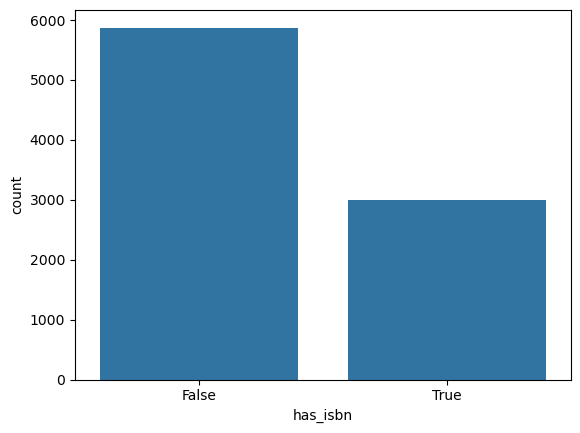

In [112]:
import seaborn as sns

sns.barplot(df1.value_counts('has_isbn'))

<Axes: xlabel='rating', ylabel='Count'>

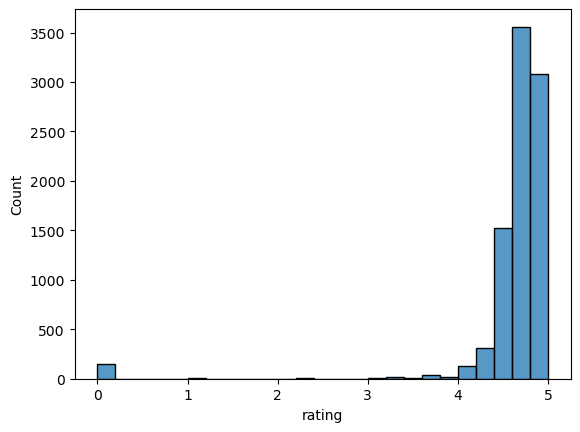

In [113]:
sns.histplot(df1['rating'], binwidth=0.2)

In [114]:
df1['rating'].describe()

count    8868.000000
mean        4.655097
std         0.669485
min         0.000000
25%         4.600000
50%         4.800000
75%         4.900000
max         5.000000
Name: rating, dtype: float64

<Axes: xlabel='rating', ylabel='Count'>

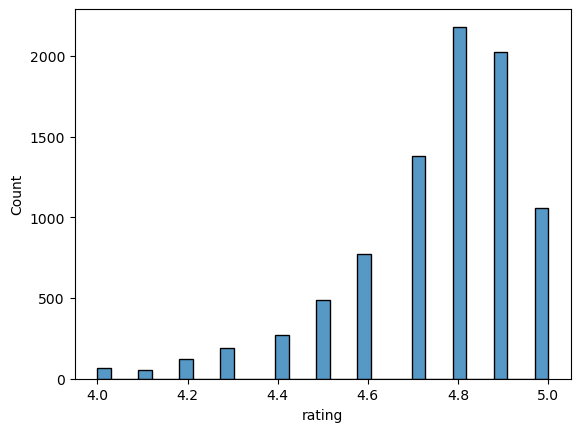

In [115]:
sns.histplot(df1[df1['rating'] >= 4]['rating'], binwidth=0.03)

In [116]:
df1['reviews_count'].isna().sum()

153

In [117]:
df1['reviews_count'].describe()

count    8715.000000
mean      665.452553
std      1165.052877
min         1.000000
25%        52.000000
50%       224.000000
75%       760.500000
max      9917.000000
Name: reviews_count, dtype: float64

In [118]:
df1['reviews_count'].isna().sum()

153

<Axes: ylabel='reviews_count'>

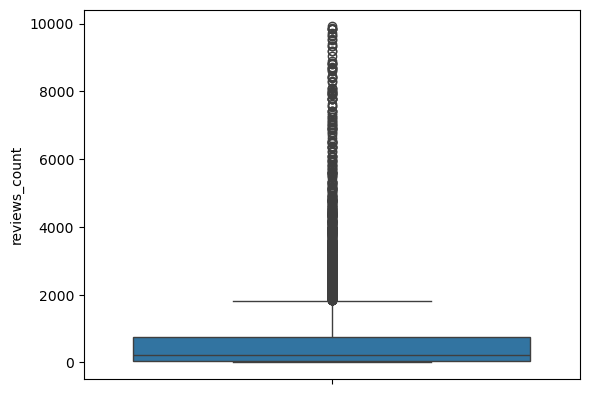

In [119]:
sns.boxplot(df1['reviews_count'])

Видно, что количества оценок больше 2000 являются выбросами. Такой график неудобно анализировать. Построим график без них

<Axes: xlabel='reviews_count', ylabel='Count'>

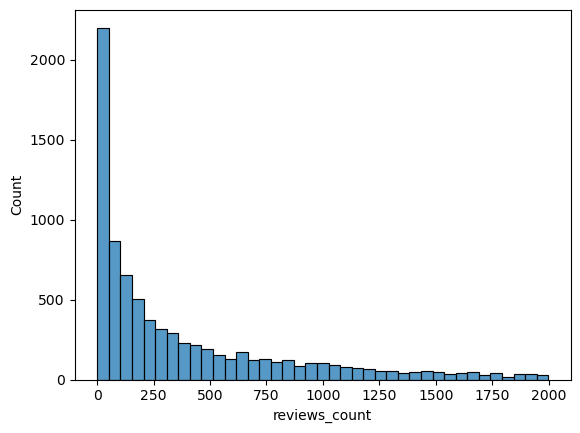

In [121]:
sns.histplot(df1[df1['reviews_count'] <= 2000]['reviews_count'])

`price`

In [123]:
df1['price'].describe()

count    8707.000000
mean      369.009971
std       183.858590
min         1.000000
25%       219.000000
50%       349.000000
75%       499.000000
max       999.000000
Name: price, dtype: float64

Text(0.5, 1.0, 'Цена книги')

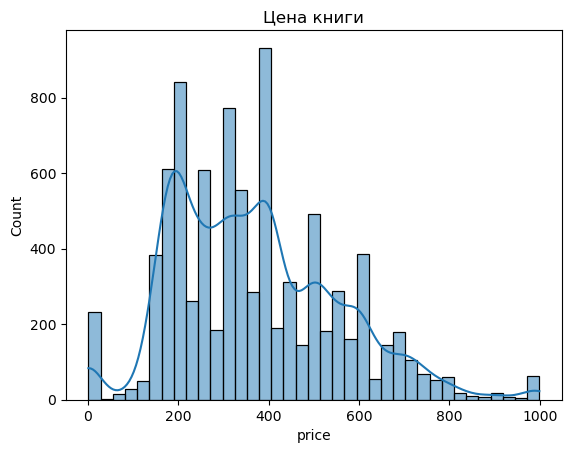

In [124]:
import matplotlib.pyplot as plt

sns.histplot(df1['price'], kde=True)
plt.title("Цена книги")

Проверим, распределены ли цены по нормальному закону

Н0: цены распределены по нормальному закону

Н1: цены не распределены по нормальному закону

In [126]:
from scipy.stats import shapiro

stat, p = shapiro(df1[~df1['price'].isna()]['price'])
p

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8707.
  res = hypotest_fun_out(*samples, **kwds)


4.2629076252585276e-41

p < 0.05, поэтому отклоняем нулевую гипотезу, цены не распределены по нормальному закону

`publication_year`

In [129]:
df1['publication_year'].astype(float).describe()

count    8268.000000
mean     2016.667755
std        24.000676
min      1170.000000
25%      2018.000000
50%      2024.000000
75%      2025.000000
max      2026.000000
Name: publication_year, dtype: float64

Text(0.5, 1.0, 'Дата публикации книги')

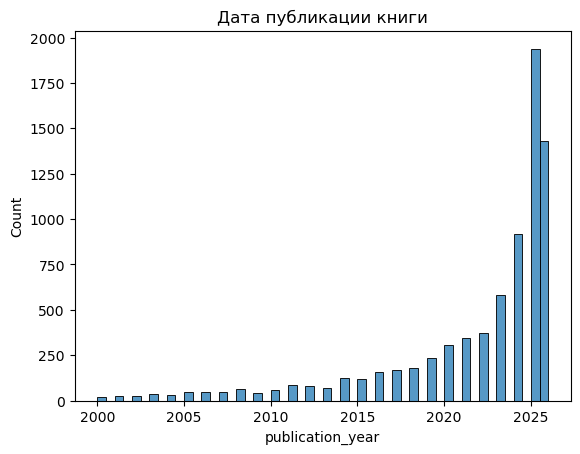

In [130]:
sns.histplot(df1[df1['publication_year'] >= 2000]['publication_year'])
plt.title("Дата публикации книги")

Самым частым является 2025 год. Это связано с тем, что за 2026 год получена еще не вся информация, так как год еще не заончился

`age_restriction`

Text(0.5, 1.0, 'Возрастные ограничения книг')

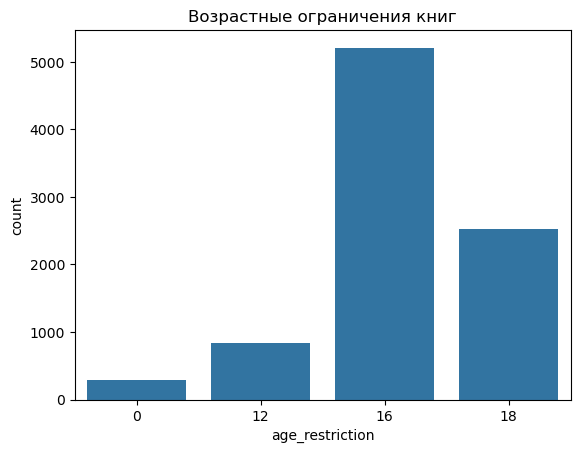

In [133]:
sns.barplot(df1['age_restriction'].value_counts())
plt.title("Возрастные ограничения книг")

Большинство книг имеют возрастное ограничение 16+, на втором месте по популярности находятся книги с возрастным ограничением 18+

`is_audiobook`

Text(0.5, 1.0, 'Является ли книга аудиокнигой')

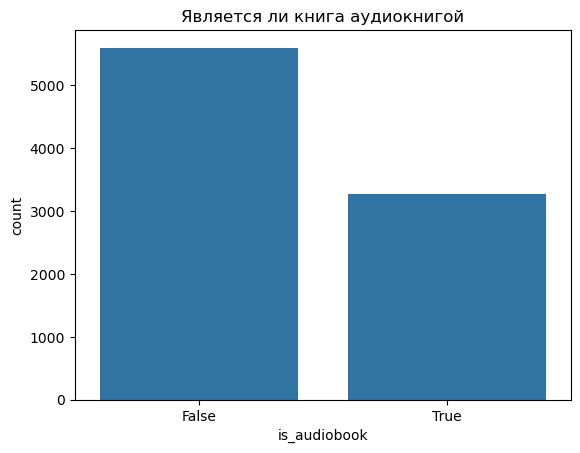

In [136]:
sns.barplot(df1.value_counts('is_audiobook'))
plt.title("Является ли книга аудиокнигой")

`lit_pages`

In [138]:
df1['lit_pages'].astype(float).describe()

count    5594.000000
mean      353.400608
std       241.704224
min         5.000000
25%       230.000000
50%       296.000000
75%       401.000000
max      3388.000000
Name: lit_pages, dtype: float64

Большинство книг имеют количество меньше 500, поэтому для удобства ограничим оси на графике этим диапазоном

Text(0.5, 1.0, 'Количество страниц')

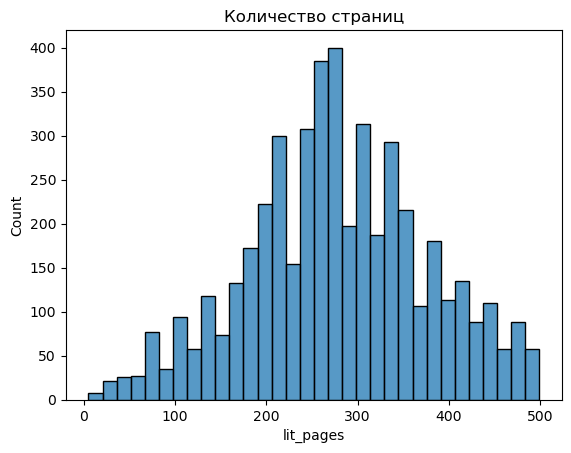

In [140]:
sns.histplot(df1[df1['lit_pages'] < 500]['lit_pages'])
plt.title("Количество страниц")

`duration`

In [142]:
df1['duration'].astype(float).describe()

count    3274.000000
mean       11.176848
std         9.956161
min         1.000000
25%         7.000000
50%         9.000000
75%        12.000000
max       291.000000
Name: duration, dtype: float64

Длительности аудиокниг редко превышают 12 часов, поэтому для удобства ограничим ось на графике

Text(0.5, 1.0, 'Длительность аудиокниги')

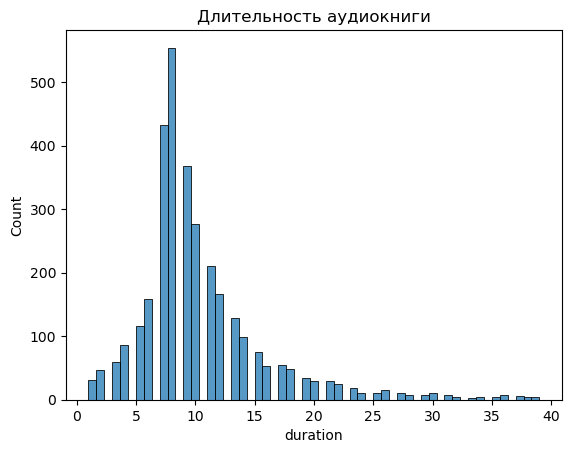

In [144]:
sns.histplot(df1[df1['duration'] < 40]['duration'])
plt.title("Длительность аудиокниги")

`retail_price`

In [146]:
df1['retail_price'].describe()

count    5017.000000
mean      410.610374
std       359.322877
min         2.746800
25%       247.212000
50%       279.258000
75%       477.943200
max      8385.980400
Name: retail_price, dtype: float64

Text(0.5, 1.0, 'Стоимость книги в google books')

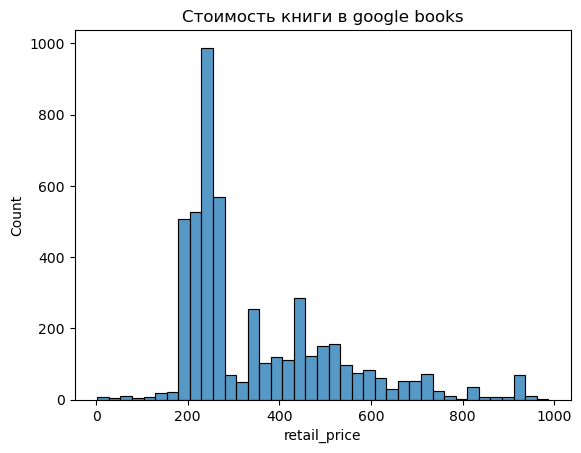

In [147]:
sns.histplot(df1[df1['retail_price'] < 1000]['retail_price'])
plt.title("Стоимость книги в google books")

Text(0.5, 1.0, 'Доступность книги на google books')

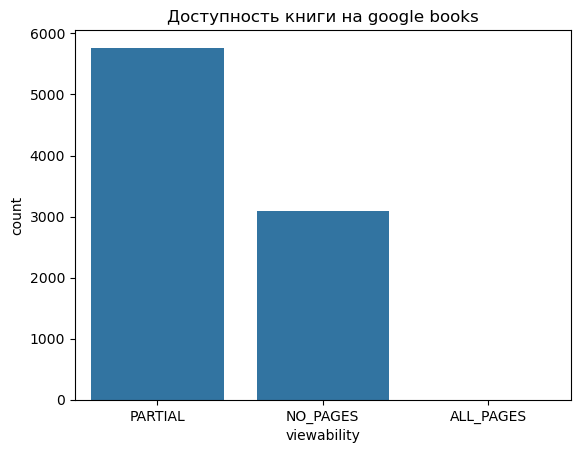

In [148]:
sns.barplot(df1.value_counts('viewability'))
plt.title("Доступность книги на google books")

`epub_avaliable`

Text(0.5, 1.0, 'Доступность epup')

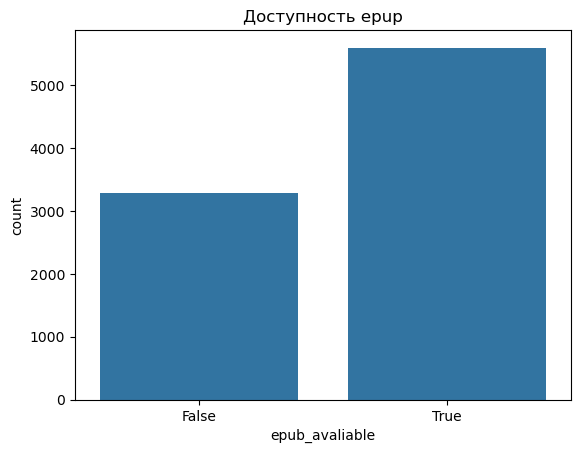

In [150]:
sns.barplot(df1.value_counts('epub_avaliable'))
plt.title("Доступность epup")

Text(0.5, 1.0, 'Доступность pdf')

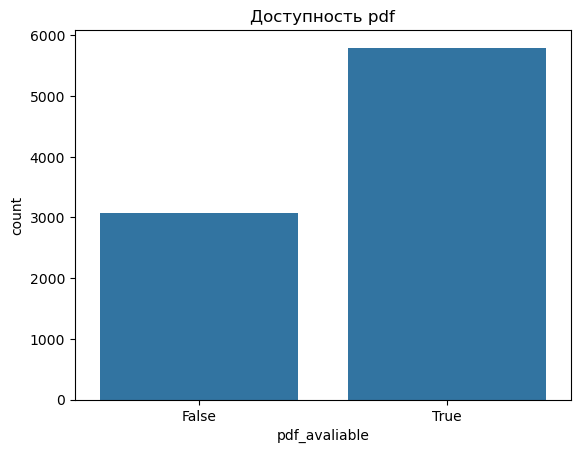

In [151]:
sns.barplot(df1.value_counts('pdf_avaliable'))
plt.title("Доступность pdf")

In [152]:
binary_cols = ['has_isbn', 'is_ebook', 'epub_avaliable', 'pdf_avaliable', 
               'genre_fantasy', 'genre_scifi', 'genre_novel', 'genre_romance',
               'genre_detective', 'genre_popad', 'genre_magic', 'genre_foreign',
               'genre_psychology', 'genre_prose', 'is_audiobook']

numeric_cols = ['rating', 'reviews_count', 'price', 'publication_year', 'age_restriction', 'lit_pages', 'retail_price', 'duration']

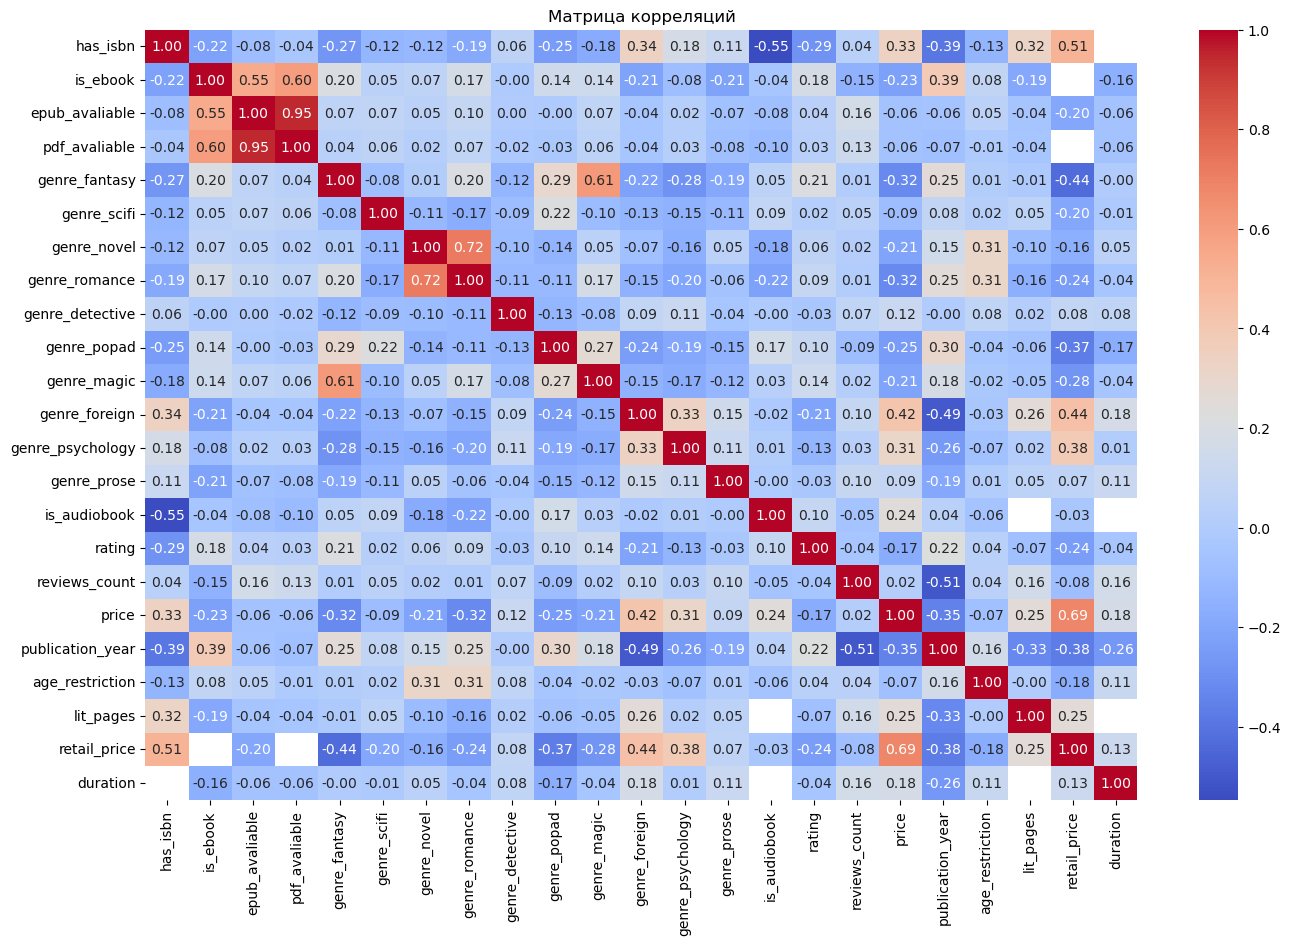

In [153]:
corr_cols = [col for col in binary_cols + numeric_cols]
corr_matrix = df1[corr_cols].corr(method='spearman')

plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляций')
plt.show()

In [154]:
top_corr = corr_matrix.unstack().reset_index()
top_corr.columns = ['feature_1', 'feature_2', 'corr']

top_corr = top_corr[top_corr['feature_1'] != top_corr['feature_2']]

top_corr['abs_corr'] = top_corr['corr'].abs()

top_corr = top_corr.sort_values('abs_corr', ascending=False)

print(top_corr.head(16))

            feature_1         feature_2      corr  abs_corr
71      pdf_avaliable    epub_avaliable  0.950696  0.950696
49     epub_avaliable     pdf_avaliable  0.950696  0.950696
167     genre_romance       genre_novel  0.717753  0.717753
145       genre_novel     genre_romance  0.717753  0.717753
500      retail_price             price  0.685805  0.685805
412             price      retail_price  0.685805  0.685805
234       genre_magic     genre_fantasy  0.607700  0.607700
102     genre_fantasy       genre_magic  0.607700  0.607700
70      pdf_avaliable          is_ebook  0.595977  0.595977
26           is_ebook     pdf_avaliable  0.595977  0.595977
322      is_audiobook          has_isbn -0.546182  0.546182
14           has_isbn      is_audiobook -0.546182  0.546182
47     epub_avaliable          is_ebook  0.545294  0.545294
25           is_ebook    epub_avaliable  0.545294  0.545294
386     reviews_count  publication_year -0.507809  0.507809
430  publication_year     reviews_count 

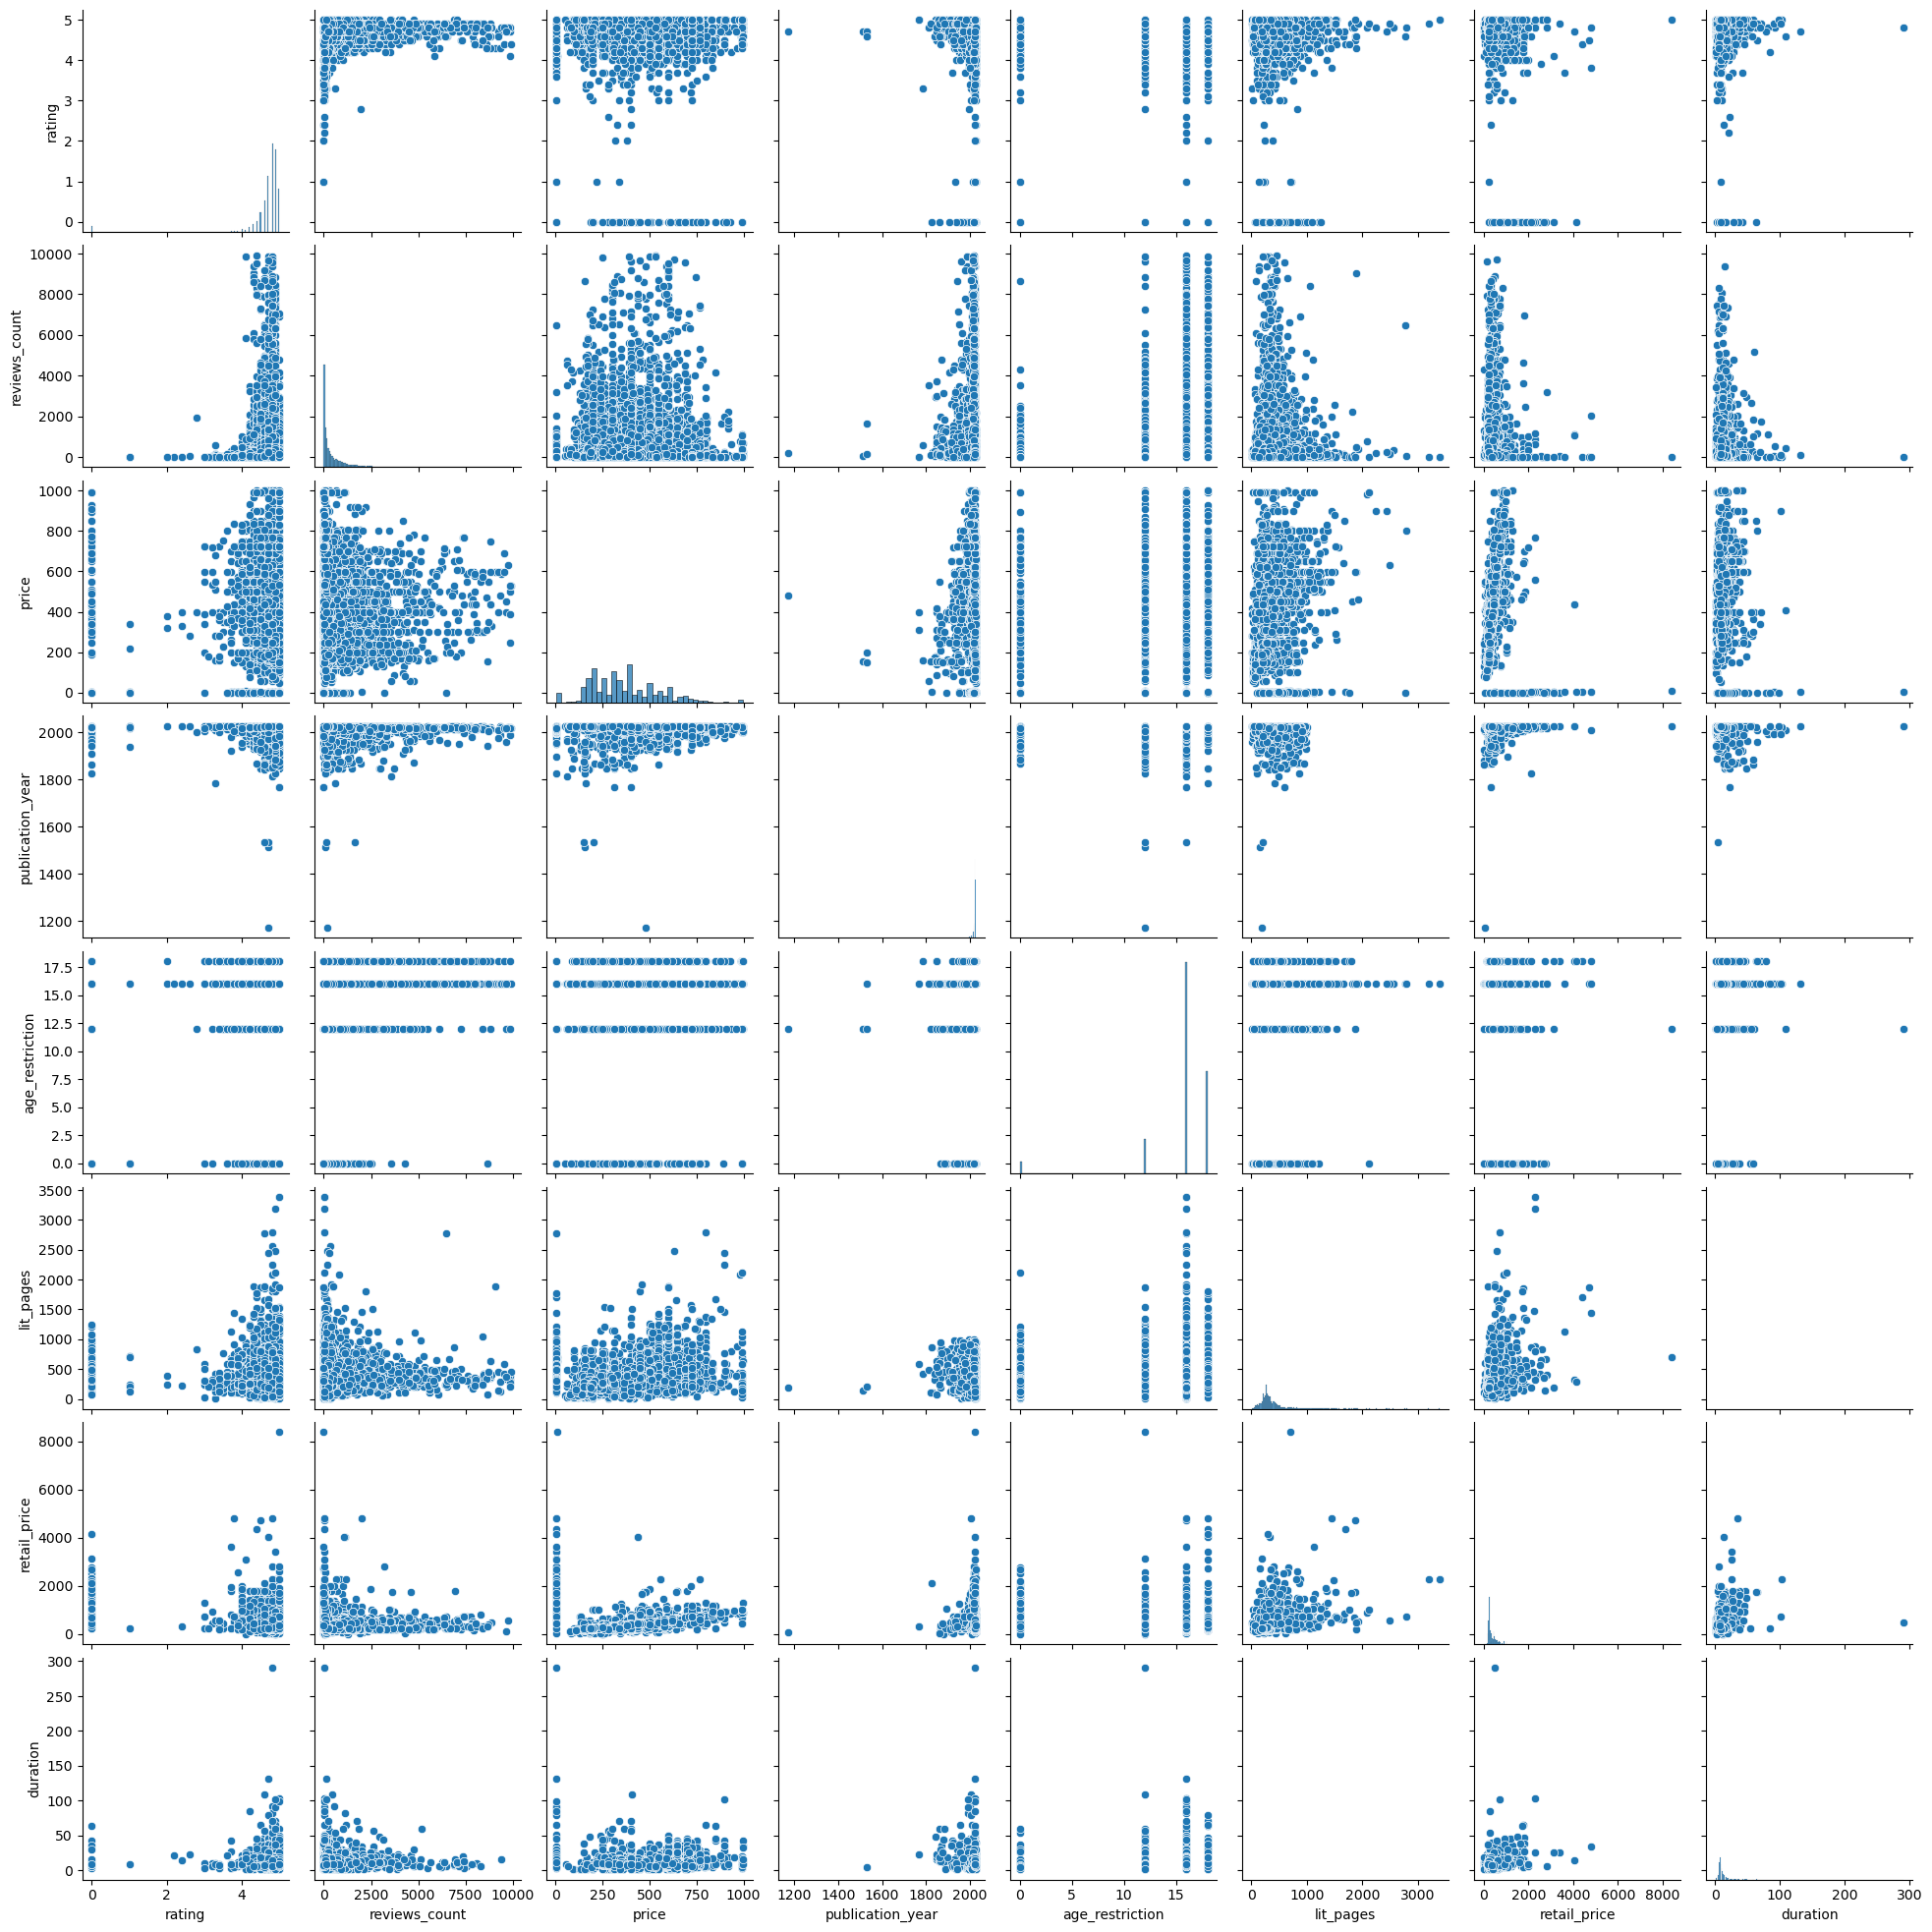

In [155]:
plot_cols = ['rating', 'reviews_count', 'price', 'publication_year', 'age_restriction', 'lit_pages', 'retail_price', 'duration']

sample_for_plot = df1[plot_cols]

sns.pairplot(sample_for_plot)
plt.show()

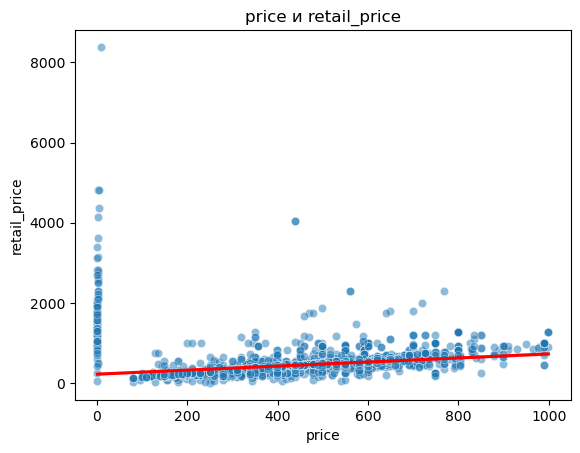

In [156]:
temp = df1[['price', 'retail_price']].dropna()
sns.scatterplot(data=temp, x='price', y='retail_price', alpha=0.5)
sns.regplot(data=temp, x='price', y='retail_price', scatter=False, color='red')
plt.title('price и retail_price')
plt.show()

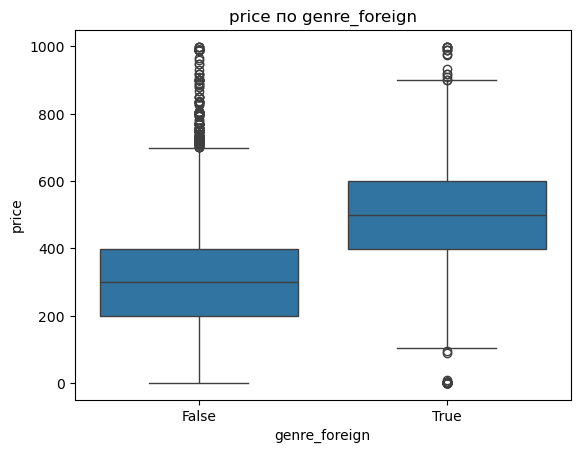

In [157]:
temp = df1[['genre_foreign', 'price']].dropna()
sns.boxplot(data=temp, x='genre_foreign', y='price')
plt.title('price по genre_foreign')
plt.show()

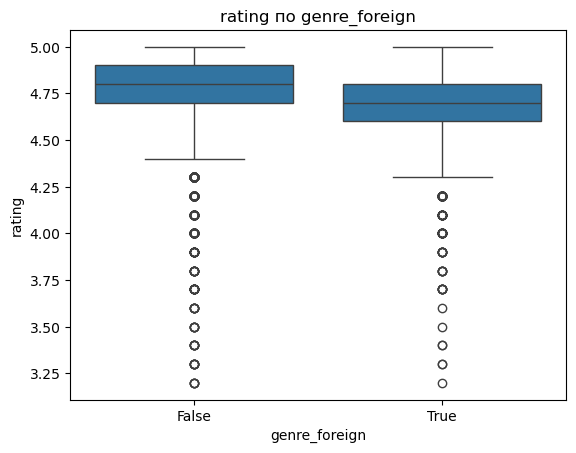

In [158]:
temp = df1[['genre_foreign', 'rating']].dropna()

q2 = temp['rating'].quantile(0.02)
q98 = temp['rating'].quantile(0.98)

temp = temp[(temp['rating'] >= q2) & (temp['rating'] <= q98)]


sns.boxplot(data=temp, x='genre_foreign', y='rating')
plt.title('rating по genre_foreign')
plt.show()

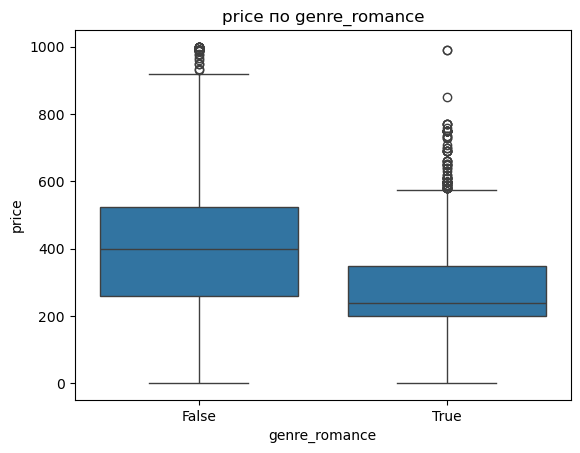

In [159]:
temp = df1[['genre_romance', 'price']].dropna()
sns.boxplot(data=temp, x='genre_romance', y='price')
plt.title('price по genre_romance')
plt.show()

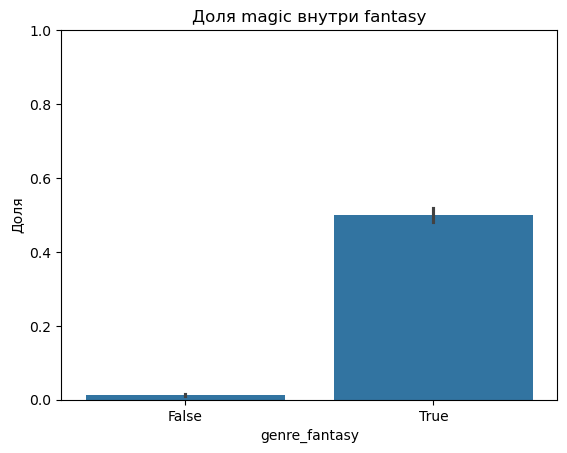

In [160]:
sns.barplot(data=df1, x='genre_fantasy', y='genre_magic')

plt.title('Доля magic внутри fantasy')
plt.xlabel('genre_fantasy')
plt.ylabel('Доля')
plt.ylim(0, 1)
plt.show()

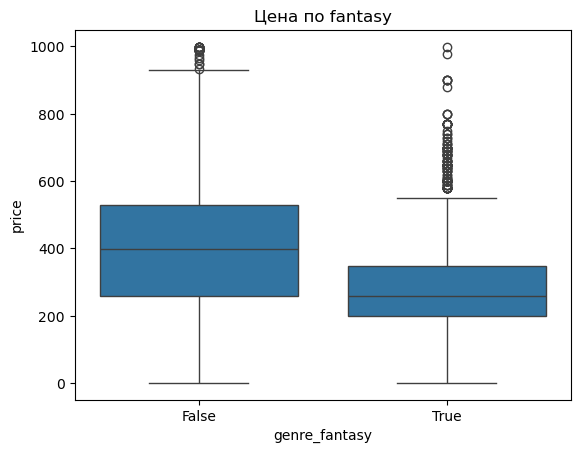

In [161]:
temp = df1[['genre_fantasy', 'price']].dropna()

sns.boxplot(data=temp, x='genre_fantasy', y='price')
plt.title('Цена по fantasy')
plt.show()

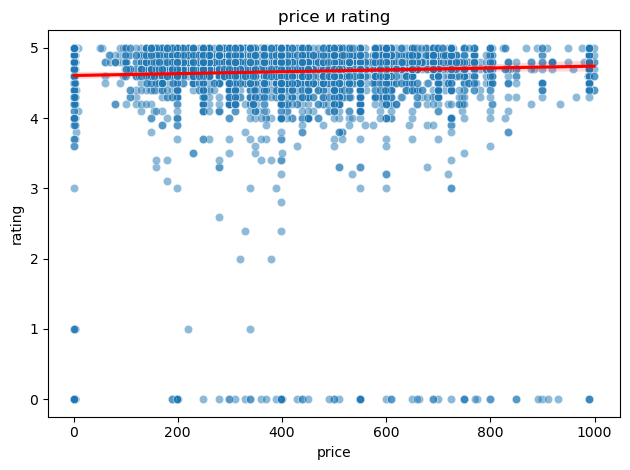

In [162]:
temp = df1[['price', 'rating']].dropna()

sns.scatterplot(data=temp, x='price', y='rating', alpha=0.5)
sns.regplot(data=temp, x='price', y='rating', scatter=False, color='red')
plt.title('price и rating')
plt.tight_layout()
plt.show()

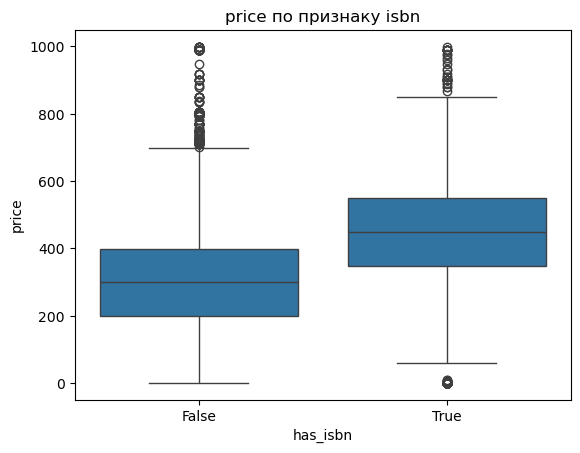

In [163]:
temp = df1[['has_isbn', 'price']].dropna()

plt.figure()
sns.boxplot(data=temp, x='has_isbn', y='price')
plt.title(f'price по признаку isbn')
plt.show()

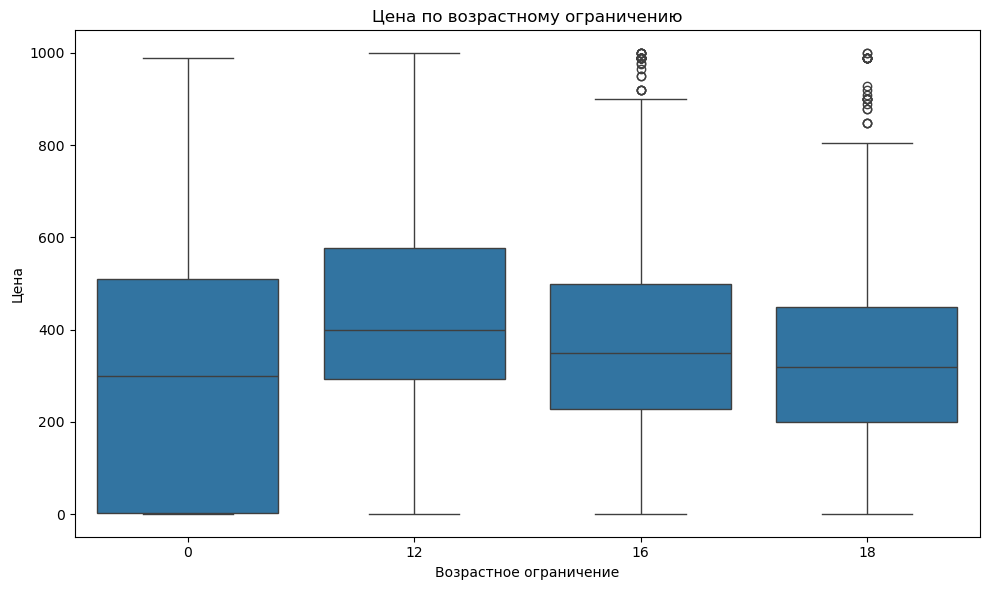

In [164]:
temp = df1[['age_restriction', 'price']].dropna()
plt.figure(figsize=(10, 6))
sns.boxplot(data=temp, x='age_restriction', y='price')
plt.title('Цена по возрастному ограничению')
plt.xlabel('Возрастное ограничение')
plt.ylabel('Цена')
plt.tight_layout()
plt.show()

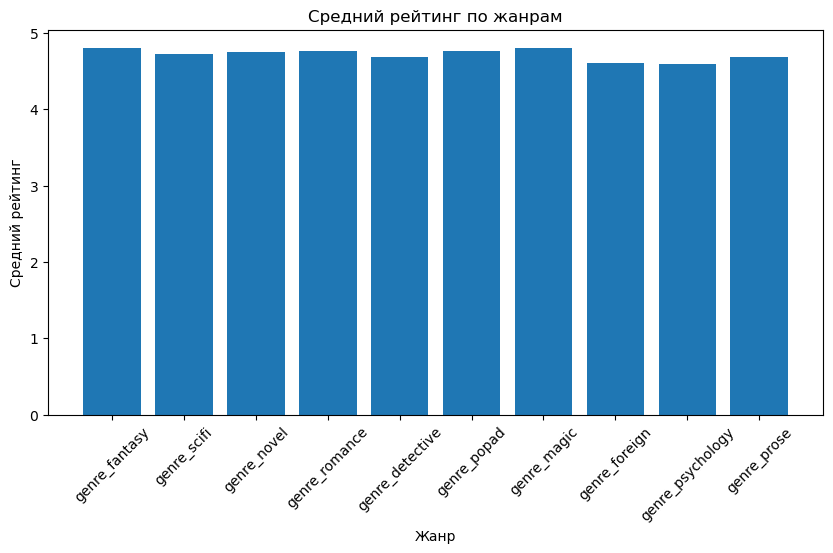

In [165]:
genres = ['genre_fantasy', 'genre_scifi', 'genre_novel', 'genre_romance', 'genre_detective', 
          'genre_popad', 'genre_magic', 'genre_foreign', 'genre_psychology', 'genre_prose']

mean_ratings = []
for genre in genres:
    mean_rating = df1[df1[genre] == 1]['rating'].mean()
    mean_ratings.append(mean_rating)

plt.figure(figsize=(10, 5))
plt.bar(genres, mean_ratings)
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.show()

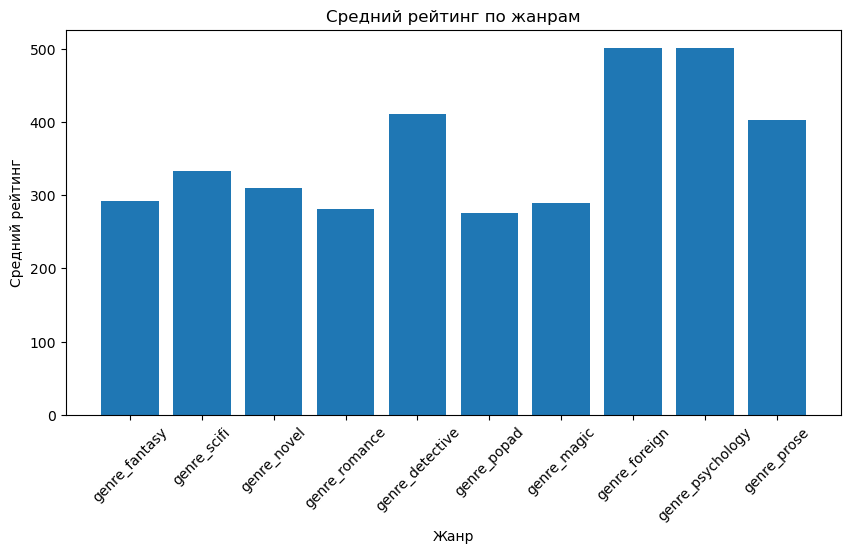

In [166]:
genres = ['genre_fantasy', 'genre_scifi', 'genre_novel', 'genre_romance', 'genre_detective', 
          'genre_popad', 'genre_magic', 'genre_foreign', 'genre_psychology', 'genre_prose']


mean_price = []
for genre in genres:
    mean_pr = df1[df1[genre] == 1]['price'].mean()
    mean_price.append(mean_pr)

plt.figure(figsize=(10, 5))
plt.bar(genres, mean_price)
plt.title('Средний рейтинг по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.show()

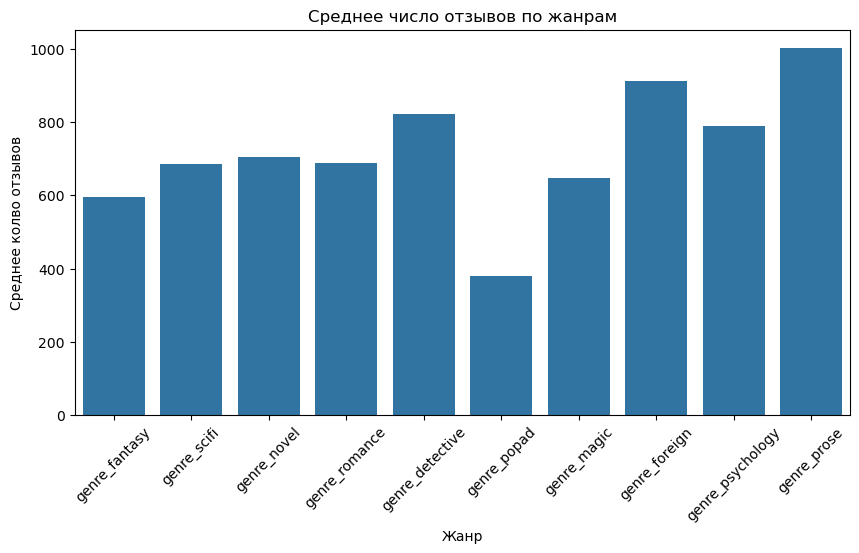

In [167]:
genres = ['genre_fantasy', 'genre_scifi', 'genre_novel', 'genre_romance', 'genre_detective', 
          'genre_popad', 'genre_magic', 'genre_foreign', 'genre_psychology', 'genre_prose']

result = []
for genre in genres:
    mean_reviews = df1[df1[genre] == 1]['reviews_count'].mean()
    result.append([genre, mean_reviews])

temp = pd.DataFrame(result, columns=['genre', 'mean_reviews_count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=temp, x='genre', y='mean_reviews_count')
plt.title('Среднее число отзывов по жанрам')
plt.xlabel('Жанр')
plt.ylabel('Среднее колво отзывов')
plt.xticks(rotation=45)
plt.show()

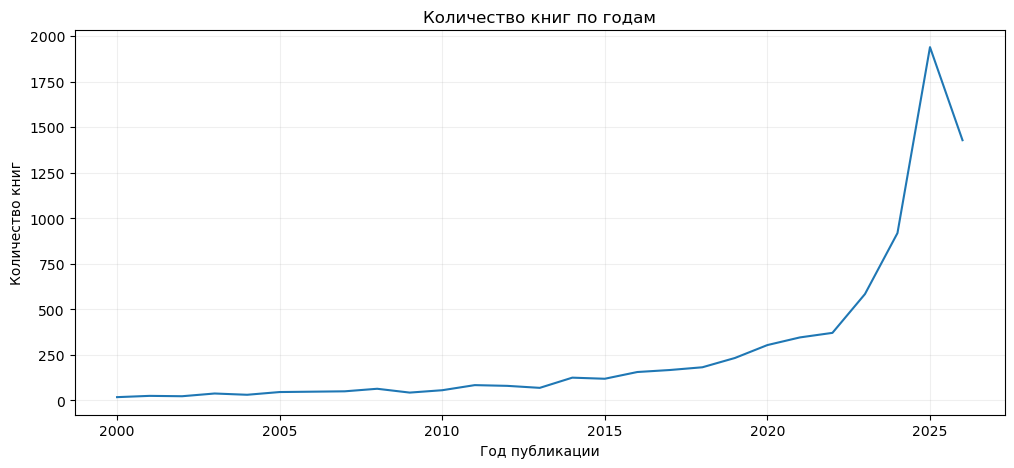

In [168]:
temp = df1['publication_year'].value_counts().sort_index()
temp = temp[temp.index >= 2000]

plt.figure(figsize=(12, 5))
plt.plot(temp.index, temp.values)
plt.title('Количество книг по годам')
plt.xlabel('Год публикации')
plt.ylabel('Количество книг')
plt.grid(alpha = 0.2)
plt.show()

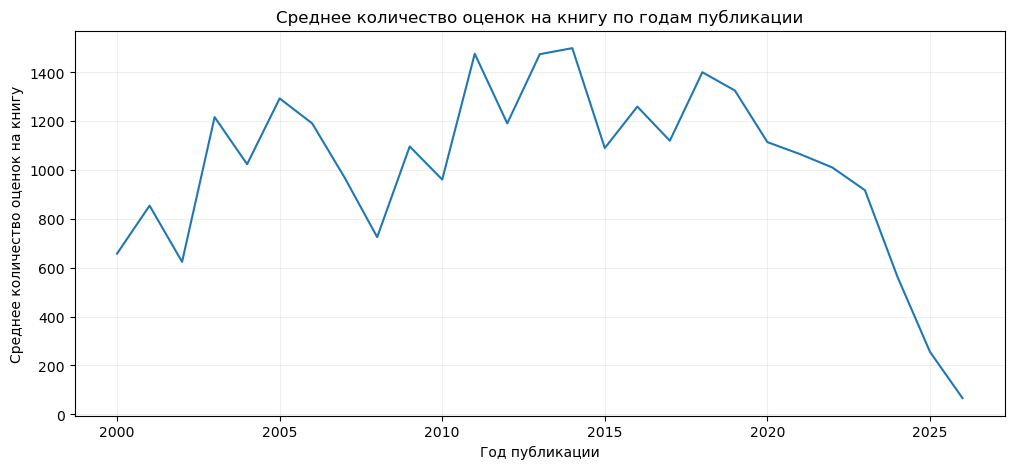

In [169]:
temp = df1.groupby('publication_year')['reviews_count'].mean()
temp = temp[temp.index >= 2000]

plt.figure(figsize=(12, 5))
plt.plot(temp.index, temp.values)
plt.title('Среднее количество оценок на книгу по годам публикации')
plt.xlabel('Год публикации')
plt.ylabel('Среднее количество оценок на книгу')
plt.grid(alpha = 0.2)
plt.show()

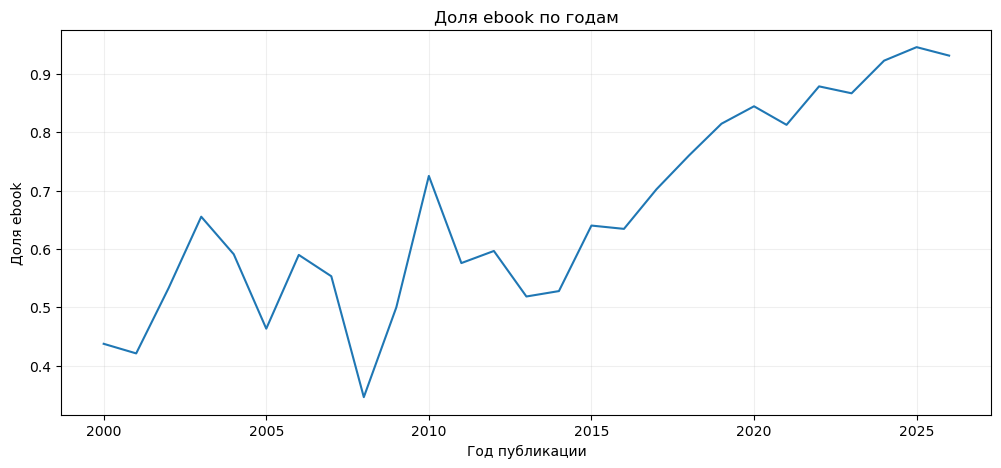

In [170]:
temp = df1[['publication_year', 'is_ebook']].dropna()

temp = temp.groupby('publication_year')['is_ebook'].agg(['count', 'mean'])
temp = temp[temp['count'] >= 10].reset_index()
temp = temp[temp['publication_year'] >= 2000]

plt.figure(figsize=(12, 5))
sns.lineplot(data=temp, x='publication_year', y='mean')
plt.title('Доля ebook по годам')
plt.xlabel('Год публикации')
plt.ylabel('Доля ebook')
plt.grid(alpha = 0.2)
plt.show()

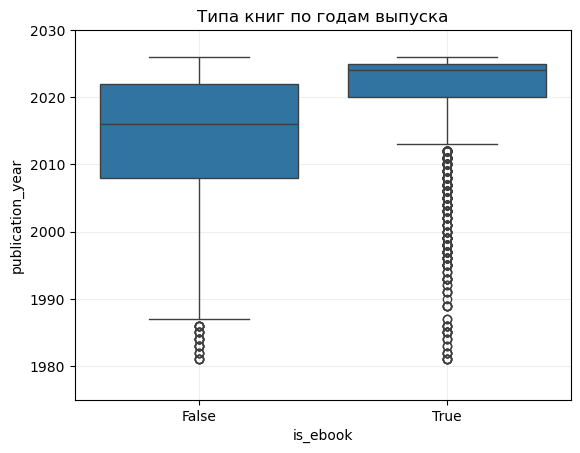

In [171]:
temp = df1[['is_ebook', 'publication_year']].dropna()

q5 = temp['publication_year'].quantile(0.05)
q95 = temp['publication_year'].quantile(0.95)

temp = temp[(temp['publication_year'] >= q5) & (temp['publication_year'] <= q95)]

sns.boxplot(data=temp, x='is_ebook', y='publication_year')
plt.ylim(1975, 2030)
plt.title('Типа книг по годам выпуска')
plt.grid(alpha = 0.2)
plt.show()

## New York Times

Рассмотрим датасет собранный из бестселлеров New York Times, обогащенный информацией из api гугл книг, hardcover api и openlibrary api

In [174]:
#df2 = pd.read_csv("google_x_nyt_final.csv")
df2 = pd.read_excel("hardcover_result.xlsx")
df2.head()

,Unnamed: 0.1,Unnamed: 0,age_group,amazon_product_url,article_chapter_link,asterisk,author,book_image,book_image_height,book_image_width,book_review_link,book_uri,contributor,contributor_note,created_date,dagger,description,first_chapter_link,price,primary_isbn10,primary_isbn13,publisher,rank,rank_last_week,sunday_review_link,title,updated_date,weeks_on_list,isbns,buy_links,avg_rating,rating_count,title_open_library,author_open_library,hardcover_title,hardcover_author,hardcover_rating,hardcover_ratings_count,release_year,users_count,genres
0,9791,38,NaN,https://www.amazon.com/dp/125031397X?tag=thene...,NaN,0,Aiden Thomas,https://static01.nyt.com/bestsellers/images/97...,500,323,NaN,nyt://book/5415bdba-f840-505b-951b-f7aab2498c65,by Aiden Thomas,NaN,2026-03-06T06:19:00.358Z,0,Wendy assists Peter Pan to find missing childr...,NaN,0,NaN,9781250313973,Swoon Reads,4,0,NaN,LOST IN THE NEVER WOODS,2026-03-06T06:19:00.358Z,1,"[{'isbn10': '', 'isbn13': '9781250313973'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Lost in the Never Woods,"['Aiden Thomas', 'Avi Roque']",Lost in the Never Woods,['Aiden Thomas' 'Avi Roque'],3.666667,39.0,2000.0,249.0,['Fantasy' 'Young Adult' 'LGBTQ' 'Young Adult ...
1,9453,491,NaN,https://www.amazon.com/dp/1464223335?tag=thene...,NaN,0,Ana Huang,https://static01.nyt.com/bestsellers/images/97...,500,324,NaN,nyt://book/fdfee028-8ada-5b4f-b380-4f0ab8aee897,by Ana Huang,NaN,2026-03-05T17:47:52.965Z,0,The second book in the Gods of the Game series...,NaN,0,NaN,9781464223334,Bloom,1,0,NaN,THE DEFENDER,2026-03-05T17:47:52.965Z,1,"[{'isbn10': '', 'isbn13': '9781464223334'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,The Defender,['Ana Huang'],The Defender,['Ana Huang'],3.954545,11.0,2025.0,31.0,['Fiction']
2,62,62,NaN,https://www.amazon.com/dp/059344129X?tag=thene...,NaN,0,Emily Henry,https://static01.nyt.com/bestsellers/images/97...,500,331,NaN,nyt://book/cec5ff36-29d1-58cc-a522-9611a0ad9fe1,by Emily Henry,NaN,2026-03-18T00:52:24.385Z,0,A writer looking for her big break competes ag...,NaN,0,NaN,9798217063987,Penguin Audio,1,0,NaN,GREAT BIG BEAUTIFUL LIFE,2026-03-18T00:52:24.385Z,0,"[{'isbn10': '', 'isbn13': '9798217063987'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Great Big Beautiful Life,['Emily Henry'],Great Big Beautiful Life,['Emily Henry'],3.845528,246.0,2025.0,704.0,['Fiction' 'Romance' 'Contemporary Romance' 'r...
3,1981,1366,NaN,https://www.amazon.com/dp/0062937405?tag=thene...,NaN,0,Meena Harris,https://static01.nyt.com/bestsellers/images/97...,500,389,NaN,nyt://book/d1fd48e8-5183-5fb2-b9be-6fc6a179f31a,by Meena Harris. Illustrated by Ana Ramírez Go...,Illustrated by Ana Ramírez González,2026-03-06T06:03:32.289Z,0,Two sisters turn their empty apartment courtya...,NaN,0,NaN,9780062937407,Balzer + Bray,5,0,NaN,KAMALA AND MAYA'S BIG IDEA,2026-03-06T06:03:32.289Z,1,"[{'isbn10': '', 'isbn13': '9780062937407'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Kamala and Maya’s Big Idea,"['Meena Harris', 'Ana Ramírez González']",Kamala and Maya’s Big Idea,['Meena Harris' 'Ana González'],4.666667,3.0,2020.0,6.0,[]
4,2290,1675,NaN,https://www.amazon.com/dp/0063221942?tag=thene...,NaN,0,Jenna Kutcher,https://static01.nyt.com/bestsellers/images/97...,500,331,NaN,nyt://book/05beddb6-4682-5cb0-8319-f37f3646e13c,by Jenna Kutcher,NaN,2026-03-06T05:18:30.124Z,1,NaN,NaN,0,NaN,9780063221949,Dey Street,7,0,NaN,"HOW ARE YOU, REALLY?",2026-03-06T05:18:30.124Z,0,"[{'isbn10': '', 'isbn13': '9780063221949'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,"How Are You, Really?",['Jenna Kutcher'],"How Are You, Really? Living Your Truth One Ans...",['Jenna Kutcher'],2.333333,3.0,2022.0,12.0,[]


In [175]:
df2.shape

(3866, 41)

Удалим заведомо ненужные для анализа столбцы

In [177]:
df2.head(5)

,Unnamed: 0.1,Unnamed: 0,age_group,amazon_product_url,article_chapter_link,asterisk,author,book_image,book_image_height,book_image_width,book_review_link,book_uri,contributor,contributor_note,created_date,dagger,description,first_chapter_link,price,primary_isbn10,primary_isbn13,publisher,rank,rank_last_week,sunday_review_link,title,updated_date,weeks_on_list,isbns,buy_links,avg_rating,rating_count,title_open_library,author_open_library,hardcover_title,hardcover_author,hardcover_rating,hardcover_ratings_count,release_year,users_count,genres
0,9791,38,NaN,https://www.amazon.com/dp/125031397X?tag=thene...,NaN,0,Aiden Thomas,https://static01.nyt.com/bestsellers/images/97...,500,323,NaN,nyt://book/5415bdba-f840-505b-951b-f7aab2498c65,by Aiden Thomas,NaN,2026-03-06T06:19:00.358Z,0,Wendy assists Peter Pan to find missing childr...,NaN,0,NaN,9781250313973,Swoon Reads,4,0,NaN,LOST IN THE NEVER WOODS,2026-03-06T06:19:00.358Z,1,"[{'isbn10': '', 'isbn13': '9781250313973'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Lost in the Never Woods,"['Aiden Thomas', 'Avi Roque']",Lost in the Never Woods,['Aiden Thomas' 'Avi Roque'],3.666667,39.0,2000.0,249.0,['Fantasy' 'Young Adult' 'LGBTQ' 'Young Adult ...
1,9453,491,NaN,https://www.amazon.com/dp/1464223335?tag=thene...,NaN,0,Ana Huang,https://static01.nyt.com/bestsellers/images/97...,500,324,NaN,nyt://book/fdfee028-8ada-5b4f-b380-4f0ab8aee897,by Ana Huang,NaN,2026-03-05T17:47:52.965Z,0,The second book in the Gods of the Game series...,NaN,0,NaN,9781464223334,Bloom,1,0,NaN,THE DEFENDER,2026-03-05T17:47:52.965Z,1,"[{'isbn10': '', 'isbn13': '9781464223334'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,The Defender,['Ana Huang'],The Defender,['Ana Huang'],3.954545,11.0,2025.0,31.0,['Fiction']
2,62,62,NaN,https://www.amazon.com/dp/059344129X?tag=thene...,NaN,0,Emily Henry,https://static01.nyt.com/bestsellers/images/97...,500,331,NaN,nyt://book/cec5ff36-29d1-58cc-a522-9611a0ad9fe1,by Emily Henry,NaN,2026-03-18T00:52:24.385Z,0,A writer looking for her big break competes ag...,NaN,0,NaN,9798217063987,Penguin Audio,1,0,NaN,GREAT BIG BEAUTIFUL LIFE,2026-03-18T00:52:24.385Z,0,"[{'isbn10': '', 'isbn13': '9798217063987'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Great Big Beautiful Life,['Emily Henry'],Great Big Beautiful Life,['Emily Henry'],3.845528,246.0,2025.0,704.0,['Fiction' 'Romance' 'Contemporary Romance' 'r...
3,1981,1366,NaN,https://www.amazon.com/dp/0062937405?tag=thene...,NaN,0,Meena Harris,https://static01.nyt.com/bestsellers/images/97...,500,389,NaN,nyt://book/d1fd48e8-5183-5fb2-b9be-6fc6a179f31a,by Meena Harris. Illustrated by Ana Ramírez Go...,Illustrated by Ana Ramírez González,2026-03-06T06:03:32.289Z,0,Two sisters turn their empty apartment courtya...,NaN,0,NaN,9780062937407,Balzer + Bray,5,0,NaN,KAMALA AND MAYA'S BIG IDEA,2026-03-06T06:03:32.289Z,1,"[{'isbn10': '', 'isbn13': '9780062937407'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,Kamala and Maya’s Big Idea,"['Meena Harris', 'Ana Ramírez González']",Kamala and Maya’s Big Idea,['Meena Harris' 'Ana González'],4.666667,3.0,2020.0,6.0,[]
4,2290,1675,NaN,https://www.amazon.com/dp/0063221942?tag=thene...,NaN,0,Jenna Kutcher,https://static01.nyt.com/bestsellers/images/97...,500,331,NaN,nyt://book/05beddb6-4682-5cb0-8319-f37f3646e13c,by Jenna Kutcher,NaN,2026-03-06T05:18:30.124Z,1,NaN,NaN,0,NaN,9780063221949,Dey Street,7,0,NaN,"HOW ARE YOU, REALLY?",2026-03-06T05:18:30.124Z,0,"[{'isbn10': '', 'isbn13': '9780063221949'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",1.0,1.0,"How Are You, Really?",['Jenna Kutcher'],"How Are You, Really? Living Your Truth One Ans...",['Jenna Kutcher'],2.333333,3.0,2022.0,12.0,[]


In [178]:
df2 = df2.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "amazon_product_url", "article_chapter_link", "asterisk", "book_image", "book_image_height",
                        "book_image_width", "book_review_link", "book_uri", "contributor", "contributor_note", "created_date", "first_chapter_link",
                        "primary_isbn10", "primary_isbn13", "sunday_review_link", "updated_date", "isbns", "buy_links", "hardcover_title", "hardcover_author",
                        "title_open_library", "author_open_library", "dagger"]) 

In [179]:
df2.shape

(3866, 16)

Переставим столбцы в более логичном для анализа порядке и переименуем некоторые столбцы для избежания разночтений

In [181]:
df2 = df2[["title", "author", "avg_rating", "rating_count", "hardcover_rating", "hardcover_ratings_count", "users_count", "price", "release_year",
           "age_group", "publisher", "genres", "description", "rank", "rank_last_week", "weeks_on_list"]]

df2 = df2.rename(columns={"avg_rating":"ol_avg_rating", "rating_count":"ol_rating_count"})

In [182]:
n_duplicates = df2.duplicated(keep=False)
df2[n_duplicates].head(10)

,title,author,ol_avg_rating,ol_rating_count,hardcover_rating,hardcover_ratings_count,users_count,price,release_year,age_group,publisher,genres,description,rank,rank_last_week,weeks_on_list


Дубликатов нет, так как они были зачищены на этапе объединения рейтингов с разных недель, до обогащения через api

#### `title`, `author`

In [185]:
df2[["title", "author"]].isna().sum()

title      0
author    25
dtype: int64

Есть 25 пропусков в `author`, посмотрим на эти строки

In [187]:
df2[df2["author"].isna()]

,title,author,ol_avg_rating,ol_rating_count,hardcover_rating,hardcover_ratings_count,users_count,price,release_year,age_group,publisher,genres,description,rank,rank_last_week,weeks_on_list
3820,A FIRST TIME FOR EVERYTHING,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,9,0,1
3821,A STUDY IN DROWNING,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,5,0,1
3822,THE SUMMER OF BROKEN RULES,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,2,0,11
3823,WE WERE LIARS,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,7,0,0
3824,FOLLOWING THE CLUES,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,14,0,1
3825,STUART WOODS' GOLDEN HOUR,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,11,0,1
3826,HIDDEN PICTURES,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,10,8,2
3827,SUNSET,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,9,0,1
3828,THE SHERIFF TAKES A WIFE,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,8,0,1
3829,THE WILD SIDE,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,7,0,1


Для этих строк, помимо автора, нет и другой информации - можно их дропнуть

In [189]:
df2 = df2.drop(index = df2[df2["author"].isna()].index)
df2 = df2.reset_index(drop = True)
df2.shape

(3841, 16)

#### `ol_avg_rating`, `ol_rating_count`, `hardcover_rating`, `hardcover_ratings_count`, `users_count`

In [191]:
df2[["ol_avg_rating", "ol_rating_count", "hardcover_rating", "hardcover_ratings_count", "users_count"]].isna().sum()

ol_avg_rating              2794
ol_rating_count            2463
hardcover_rating            284
hardcover_ratings_count     284
users_count                 284
dtype: int64

Рейтингам из open_library мы доверям больше, но там достаточно много пропусков, и большую часть строк пришлось бы не учитывать в анализе. Поэтому заполним пропуски в рейтинге `ol_avg_rating` рейтингом `hardcover_rating`, так как они формируются по одной и той же схеме - среднее оценка текста по оценкам по всем изданиям этого текста.  

In [193]:
df2["ol_rating_count"] = np.where(df2["ol_avg_rating"].isna(), df2["hardcover_ratings_count"], df2["ol_rating_count"])
df2["ol_avg_rating"] = np.where(df2["ol_avg_rating"].isna(), df2["hardcover_rating"], df2["ol_avg_rating"])

In [194]:
df2 = df2.drop(columns=["hardcover_ratings_count", "hardcover_rating"])

In [195]:
df2

,title,author,ol_avg_rating,ol_rating_count,users_count,price,release_year,age_group,publisher,genres,description,rank,rank_last_week,weeks_on_list
0,LOST IN THE NEVER WOODS,Aiden Thomas,1.000000,1.0,249.0,0,2000.0,NaN,Swoon Reads,['Fantasy' 'Young Adult' 'LGBTQ' 'Young Adult ...,Wendy assists Peter Pan to find missing childr...,4,0,1
1,THE DEFENDER,Ana Huang,1.000000,1.0,31.0,0,2025.0,NaN,Bloom,['Fiction'],The second book in the Gods of the Game series...,1,0,1
2,GREAT BIG BEAUTIFUL LIFE,Emily Henry,1.000000,1.0,704.0,0,2025.0,NaN,Penguin Audio,['Fiction' 'Romance' 'Contemporary Romance' 'r...,A writer looking for her big break competes ag...,1,0,0
3,KAMALA AND MAYA'S BIG IDEA,Meena Harris,1.000000,1.0,6.0,0,2020.0,NaN,Balzer + Bray,[],Two sisters turn their empty apartment courtya...,5,0,1
4,"HOW ARE YOU, REALLY?",Jenna Kutcher,1.000000,1.0,12.0,0,2022.0,NaN,Dey Street,[],NaN,7,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3836,"JESSI RAMSEY, PET-SITTER",Ann M. Martin,3.250000,8.0,15.0,0,1989.0,NaN,Scholastic,['Friendship' 'Fiction' 'Young Adult' 'Juvenil...,The 18th book in the Baby-Sitters Club graphic...,7,0,3
3837,THE OVERTHINKER'S GUIDE TO MAKING DECISIONS,Joseph Nguyen,0.000000,0.0,16.0,0,2025.0,NaN,Authors Equity,['Self-Help'],NaN,6,0,2
3838,STRONG GROUND,Brené Brown,0.000000,0.0,1.0,0,2025.0,NaN,Random House,[],NaN,3,2,2
3839,KINGDOM OF ASH,Sarah J. Maas,4.509124,822.0,1718.0,0,2018.0,NaN,Audible Studios,['Fantasy' 'Young Adult' 'Science Fiction & Fa...,The seventh book in the Throne of Glass series...,11,0,0
